# Clustering Grid Search Analysis: Builds, Demos, and Renos

## Preliminaries

In [59]:
# Imports

# General
import numpy as np
import pandas as pd
import json
import itertools
import time
from IPython.display import display
import random
from joblib import Memory
from datetime import datetime

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'iframe' # For plotly graphs to render in this environment

# Geography
import geopandas as gpd
from shapely.geometry import Point, Polygon


# NLP
import re
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
import nltk, pprint
pprint.pp(nltk.data.path)
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet as wn
from nltk.corpus import names
import pycountry

# sk-learn modeling
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid
from sklearn.decomposition import TruncatedSVD
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.base import clone
from sklearn.metrics import (
        silhouette_score,
        silhouette_samples,
        davies_bouldin_score, 
        calinski_harabasz_score)


['C:\\Users\\emshe/nltk_data',
 'C:\\Users\\emshe\\anaconda3\\envs\\capstone_env\\nltk_data',
 'C:\\Users\\emshe\\anaconda3\\envs\\capstone_env\\share\\nltk_data',
 'C:\\Users\\emshe\\anaconda3\\envs\\capstone_env\\lib\\nltk_data',
 'C:\\Users\\emshe\\AppData\\Roaming\\nltk_data',
 'C:\\nltk_data',
 'D:\\nltk_data',
 'E:\\nltk_data']


In [60]:
# Set directory

PATH = "C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA"

In [61]:
# Load permits data

permits_df = pd.read_csv(f"{PATH}/PERMITS/issued_building_permits_filter_dwelling_purposes_preprocessed.csv")

examine_df('permits dataframe',permits_df)



Number of records in the permits dataframe is: 25417


Number of features in the permits dataframe is: 19

The columns in the permits dataframe are: Index(['issue_date', 'project_description', 'geom', 'project_value', 'nbhd',
       'zone', 'duplex_w_secondary_suite', 'laneway_house', 'duplex',
       'multiple_conversion_dwelling', 'dwelling_unit', 'multiple_dwelling',
       'single_detached_house', 'single_detached_house_w_sec_suite',
       'type_of_work_demolition_deconstruction', 'type_of_work_new_building',
       'permit_category_new_build_low_density_housing',
       'permit_category_new_build_standalone_laneway',
       'permit_category_renovation_residential_lower_complexity'],
      dtype='object')


 Other info about permits dataframe:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25417 entries, 0 to 25416
Data columns (total 19 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                

None


 Basic statistical info about permits dataframe:



,project_value,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite,type_of_work_demolition_deconstruction,type_of_work_new_building,permit_category_new_build_low_density_housing,permit_category_new_build_standalone_laneway,permit_category_renovation_residential_lower_complexity
count,2.541700e+04,25417.000000,25417.000000,25417.000000,25417.000000,25417.000000,25417.000000,25417.000000,25417.000000,25417.000000,25417.000000,25417.000000,25417.000000,25417.000000
mean,8.814701e+05,0.026754,0.148601,0.058937,0.013456,0.023528,0.210725,0.319432,0.181650,0.224810,0.372349,0.257820,0.079278,0.309832
std,9.295619e+06,0.161366,0.355702,0.235511,0.115217,0.151575,0.407832,0.466266,0.385563,0.417465,0.483440,0.437443,0.270177,0.462433
min,5.053050e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.749044e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.010610e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.078863e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000
max,8.408412e+08,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000




Sample of records in the permits dataframe:


,issue_date,project_description,geom,project_value,nbhd,zone,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite,type_of_work_demolition_deconstruction,type_of_work_new_building,permit_category_new_build_low_density_housing,permit_category_new_build_standalone_laneway,permit_category_renovation_residential_lower_complexity
0,2017-04-12,Low Density Housing - New Building - To constr...,POINT (-123.0438851 49.2545202),250115.294118,Renfrew,Mount Pleasant/Renfrew Heights,0,0,0,0,0,0,0,1,0,1,1,0,0
1,2022-11-14,Low Density Housing - Demolition / Deconstruct...,POINT (-123.0677731 49.2249324),15625.427204,Fraser View/Killarny,Southeast Vancouver,0,0,0,0,0,0,1,0,1,0,0,0,0
2,2017-08-23,Field Review - Demolition / Deconstruction - T...,POINT (-123.1211653 49.2588709),75669.289412,South Granville,South Granville/Oak,0,0,0,0,0,1,0,0,1,0,0,0,0
3,2017-09-28,Low Density Housing - New Building - To constr...,POINT (-123.0846679 49.2365573),183866.117647,Sunset,Southeast Vancouver,0,1,0,0,0,0,0,0,0,1,0,1,0
4,2018-08-03,Low Density Housing - Demolition / Deconstruct...,POINT (-123.0894871 49.239411),17490.436113,Sunset,Southeast Vancouver,0,0,0,0,0,0,0,1,1,0,0,0,0


## Define helper functions

In [62]:
# Define function to examine dataframes

def examine_df(name,df,
               include_stats = True,
               include_sample = True):
    
    """
    Check basic info about a dataframe df
    """
    
    print(f"\n\nNumber of records in the {name} is: {len(df)}\n")
    print(f"\nNumber of features in the {name} is: {len(df.columns)}\n")
    print(f"The columns in the {name} are: {df.columns}\n")
    print(f"\n Other info about {name}:\n")
    display(df.info())
    if include_stats == True:
        print(f'\n Basic statistical info about {name}:\n')
        display(df.describe())
    if include_sample == True:
        print(f"\n\nSample of records in the {name}:")
        display(df.head(5))

In [63]:
# Define functions to detect binary columns vs. continuous functions

def is_binary(series: pd.Series) -> bool:

    '''
    Detect binary columns in series
    '''
    
    vals = series.dropna().unique()
    return set(vals).issubset({0, 1}) and len(vals) <= 2

def select_binary_cols(X):

    '''
    Select subset of binary columns
    '''
    
    return [c for c in X.columns
            if c != "project_description"
            and is_binary(X[c])]

def select_cont_cols(X):

    '''
    Select subset of continuous columns
    '''
    
    cols = []
    for c in X.columns:
        if c == "project_description":
            continue
        s = X[c]
        # numeric dtype
        if np.issubdtype(s.dtype, np.number):
            if not is_binary(s):
                cols.append(c)
    return cols

In [64]:
# Define function to drop trivial columns from dataframe

def drop_trivial(df):

    """
    Drop all trivial (all 1 or all 0) columns from a dataframe
    """

    n_rows = len(df)
    
    to_drop = []

    for col in df.columns:
        if is_binary(df[col]) and (df[col].sum() == 0 or df[col].sum() == n_rows):
            to_drop.append(col)

    df = df.drop(columns = to_drop)
    return df

In [65]:
# Define function to make permit sub-dataframe model ready

def model_ready(df):

    """
    Drop columns that won't be used in modeling
    """

    return df.drop(columns = ['issue_date', 'geom','nbhd','zone'])

## Split Up Permits

In [66]:
# Get dataframes of new builds (one with all info, one for modeling)

is_new_building = (permits_df['type_of_work_new_building'] == 1) | (permits_df['permit_category_new_build_low_density_housing'] == 1) | (permits_df['permit_category_new_build_standalone_laneway'] == 1)

builds_df = permits_df[is_new_building]

builds_df = drop_trivial(builds_df)

cluster_builds_df = model_ready(builds_df)

examine_df('buildings dataframe', cluster_builds_df)



Number of records in the buildings dataframe is: 9464


Number of features in the buildings dataframe is: 12

The columns in the buildings dataframe are: Index(['project_description', 'project_value', 'duplex_w_secondary_suite',
       'laneway_house', 'duplex', 'multiple_conversion_dwelling',
       'dwelling_unit', 'multiple_dwelling', 'single_detached_house',
       'single_detached_house_w_sec_suite',
       'permit_category_new_build_low_density_housing',
       'permit_category_new_build_standalone_laneway'],
      dtype='object')


 Other info about buildings dataframe:

<class 'pandas.core.frame.DataFrame'>
Index: 9464 entries, 0 to 25414
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   project_description                            9464 non-null   object 
 1   project_value                                  9464 non-null   float64
 2   d

None


 Basic statistical info about buildings dataframe:



,project_value,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite,permit_category_new_build_low_density_housing,permit_category_new_build_standalone_laneway
count,9.464000e+03,9464.000000,9464.000000,9464.000000,9464.000000,9464.000000,9464.000000,9464.000000,9464.000000,9464.000000,9464.000000
mean,2.130362e+06,0.059277,0.392434,0.096682,0.001162,0.004121,0.064138,0.137997,0.225592,0.692413,0.212912
std,1.512969e+07,0.236155,0.488318,0.295540,0.034074,0.064065,0.245011,0.344915,0.417993,0.461519,0.409388
min,1.019777e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.388613e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.070169e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,9.785543e+05,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,8.408412e+08,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000




Sample of records in the buildings dataframe:


,project_description,project_value,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite,permit_category_new_build_low_density_housing,permit_category_new_build_standalone_laneway
0,Low Density Housing - New Building - To constr...,2.501153e+05,0,0,0,0,0,0,0,1,1,0
3,Low Density Housing - New Building - To constr...,1.838661e+05,0,1,0,0,0,0,0,0,0,1
14,Low Density Housing - New Building - To constr...,8.857129e+05,0,0,0,0,0,0,1,0,1,0
23,Low Density Housing - New Building - To constr...,9.618750e+05,1,0,0,0,0,0,0,0,1,0
26,Low Density Housing - New Building - To constr...,1.056125e+06,1,0,0,0,0,0,0,0,1,0


In [67]:
# Get dataframe of renovations (one with all info, one for modeling)

renos_df = permits_df[permits_df['permit_category_renovation_residential_lower_complexity'] == 1]

renos_df = drop_trivial(renos_df)

cluster_renos_df = model_ready(renos_df)

examine_df('renovations dataframe', cluster_renos_df)



Number of records in the renovations dataframe is: 7875


Number of features in the renovations dataframe is: 10

The columns in the renovations dataframe are: Index(['project_description', 'project_value', 'duplex_w_secondary_suite',
       'laneway_house', 'duplex', 'multiple_conversion_dwelling',
       'dwelling_unit', 'multiple_dwelling', 'single_detached_house',
       'single_detached_house_w_sec_suite'],
      dtype='object')


 Other info about renovations dataframe:

<class 'pandas.core.frame.DataFrame'>
Index: 7875 entries, 8 to 25416
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   project_description                7875 non-null   object 
 1   project_value                      7875 non-null   float64
 2   duplex_w_secondary_suite           7875 non-null   int64  
 3   laneway_house                      7875 non-null   int64  
 4   duplex                  

None


 Basic statistical info about renovations dataframe:



,project_value,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite
count,7.875000e+03,7875.000000,7875.000000,7875.000000,7875.000000,7875.000000,7875.000000,7875.000000,7875.000000
mean,9.536062e+04,0.001016,0.003810,0.026032,0.018159,0.049270,0.501968,0.252698,0.131556
std,2.235591e+05,0.031859,0.061608,0.159240,0.133534,0.216445,0.500028,0.434587,0.338028
min,5.053050e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.594619e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,9.434814e+04,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,6.000000e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000




Sample of records in the renovations dataframe:


,project_description,project_value,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite
8,Field Review - Addition / Alteration - #308\n\...,26818.668707,0,0,0,0,0,1,0,0
9,Field Review - Addition / Alteration - Exterio...,221995.630007,0,0,0,0,0,0,1,0
12,Field Review - Addition / Alteration - Interio...,119794.941900,0,0,0,1,0,0,0,0
13,Field Review - Addition / Alteration - Exterio...,60961.195294,0,0,0,0,0,0,0,1
15,Field Review - Addition / Alteration - Exterio...,58828.841952,0,0,0,0,0,1,0,0


In [68]:
# Get dataframe of demolitions

demos_df = permits_df[permits_df['type_of_work_demolition_deconstruction'] == 1]

demos_df = drop_trivial(demos_df)

cluster_demos_df = model_ready(demos_df)

examine_df('demolitions dataframe', cluster_demos_df)



Number of records in the demolitions dataframe is: 5714


Number of features in the demolitions dataframe is: 10

The columns in the demolitions dataframe are: Index(['project_description', 'project_value', 'duplex_w_secondary_suite',
       'laneway_house', 'duplex', 'multiple_conversion_dwelling',
       'dwelling_unit', 'multiple_dwelling', 'single_detached_house',
       'single_detached_house_w_sec_suite'],
      dtype='object')


 Other info about demolitions dataframe:

<class 'pandas.core.frame.DataFrame'>
Index: 5714 entries, 1 to 25415
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   project_description                5714 non-null   object 
 1   project_value                      5714 non-null   float64
 2   duplex_w_secondary_suite           5714 non-null   int64  
 3   laneway_house                      5714 non-null   int64  
 4   duplex                  

None


 Basic statistical info about demolitions dataframe:



,project_value,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite
count,5.714000e+03,5714.000000,5714.000000,5714.000000,5714.000000,5714.000000,5714.000000,5714.000000,5714.000000
mean,2.693202e+04,0.019251,0.002275,0.049527,0.002625,0.013651,0.016451,0.700385,0.190060
std,1.215656e+05,0.137418,0.047648,0.216986,0.051173,0.116046,0.127213,0.458129,0.392382
min,1.109978e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.562543e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.708520e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,1.792941e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,6.500000e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000




Sample of records in the demolitions dataframe:


,project_description,project_value,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite
1,Low Density Housing - Demolition / Deconstruct...,15625.427204,0,0,0,0,0,0,1,0
2,Field Review - Demolition / Deconstruction - T...,75669.289412,0,0,0,0,0,1,0,0
4,Low Density Housing - Demolition / Deconstruct...,17490.436113,0,0,0,0,0,0,0,1
20,Low Density Housing - Demolition / Deconstruct...,15000.000000,0,0,0,0,0,0,1,0
21,Low Density Housing - Demolition / Deconstruct...,16649.672251,0,0,0,0,0,0,1,0


In [69]:
# Get dataframe with no renovations, no demolitions

not_reno = (permits_df['permit_category_renovation_residential_lower_complexity'] == 0)

not_demo = (permits_df['type_of_work_demolition_deconstruction'] == 0)

restr_df = permits_df[not_reno & not_demo]

restr_df = drop_trivial(restr_df)

cluster_restr_df = model_ready(restr_df)

examine_df('restricted dataframe (no renovations or demolitions)', cluster_restr_df)



Number of records in the restricted dataframe (no renovations or demolitions) is: 11828


Number of features in the restricted dataframe (no renovations or demolitions) is: 13

The columns in the restricted dataframe (no renovations or demolitions) are: Index(['project_description', 'project_value', 'duplex_w_secondary_suite',
       'laneway_house', 'duplex', 'multiple_conversion_dwelling',
       'dwelling_unit', 'multiple_dwelling', 'single_detached_house',
       'single_detached_house_w_sec_suite', 'type_of_work_new_building',
       'permit_category_new_build_low_density_housing',
       'permit_category_new_build_standalone_laneway'],
      dtype='object')


 Other info about restricted dataframe (no renovations or demolitions):

<class 'pandas.core.frame.DataFrame'>
Index: 11828 entries, 0 to 25414
Data columns (total 13 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  ---

None


 Basic statistical info about restricted dataframe (no renovations or demolitions):



,project_value,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite,type_of_work_new_building,permit_category_new_build_low_density_housing,permit_category_new_build_standalone_laneway
count,1.182800e+04,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000
mean,1.817676e+06,0.047514,0.315692,0.085391,0.015556,0.011160,0.110670,0.179828,0.210940,0.800135,0.554024,0.170358
std,1.356499e+07,0.212745,0.464810,0.279474,0.123756,0.105054,0.313736,0.384060,0.407993,0.399915,0.497094,0.375963
min,8.084881e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.135412e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,5.948079e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,9.369729e+05,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,8.408412e+08,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000




Sample of records in the restricted dataframe (no renovations or demolitions):


,project_description,project_value,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite,type_of_work_new_building,permit_category_new_build_low_density_housing,permit_category_new_build_standalone_laneway
0,Low Density Housing - New Building - To constr...,2.501153e+05,0,0,0,0,0,0,0,1,1,1,0
3,Low Density Housing - New Building - To constr...,1.838661e+05,0,1,0,0,0,0,0,0,1,0,1
5,High Density Housing / Commercial - Addition /...,4.556054e+06,0,0,0,1,0,0,0,0,0,0,0
6,High Density Housing / Commercial - Addition /...,1.912471e+05,0,0,0,0,0,1,0,0,0,0,0
7,High Density Housing / Commercial - Addition /...,5.948079e+05,0,0,0,0,0,1,0,0,0,0,0


## K-Means Grid Searches

### Builds

In [72]:
# Load first builds grid search results

builds_results_list = []

builds_results_01 = read_grid_results_csv('BUILDS','01_kmeans_grid_results_builds.csv')

builds_results_list.append(builds_results_01)

examine_df('first builds results', builds_results_01)



Number of records in the first builds results is: 96


Number of features in the first builds results is: 9

The columns in the first builds results are: Index(['kmeans__n_clusters', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'inertia', 'silhouette',
       'calinski_harabasz', 'davies_bouldin', 'fit_time_s',
       'n_clusters_found'],
      dtype='object')


 Other info about first builds results:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   kmeans__n_clusters               96 non-null     int64  
 1   prep__text__svd__n_components    96 non-null     int64  
 2   prep__text__tfidf__max_features  96 non-null     int64  
 3   inertia                          96 non-null     float64
 4   silhouette                       96 non-null     float64
 5   calinski_harabasz    

None


 Basic statistical info about first builds results:



,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,fit_time_s,n_clusters_found
count,96.000000,96.00000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,4.666667,35.00000,500.000000,314146.970141,0.057277,367.789747,3.745368,58.116250,4.666667
std,1.982379,11.23903,309.838668,107219.051185,0.039138,143.982752,0.860735,12.401250,1.982379
min,2.000000,20.00000,200.000000,143774.232630,-0.050886,192.174883,2.248930,54.903397,2.000000
25%,3.000000,27.50000,275.000000,228262.678430,0.032471,262.465164,3.130799,55.460768,3.000000
50%,4.500000,35.00000,400.000000,313446.379207,0.054001,335.110707,3.685710,55.742152,4.500000
75%,6.000000,42.50000,625.000000,398867.520086,0.083203,454.656788,4.302675,56.104079,6.000000
max,8.000000,50.00000,1000.000000,482853.779865,0.163456,687.223242,6.651000,128.763356,8.000000




Sample of records in the first builds results:


,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,fit_time_s,n_clusters_found
0,2,20,200,195868.892385,0.066285,651.408079,3.616294,125.423324,2
1,2,20,300,195888.467534,0.079626,650.397070,3.709790,125.342084,2
2,2,20,500,195177.708474,0.099575,687.223242,3.397221,128.763356,2
3,2,20,1000,195614.311793,0.081347,664.569713,3.558461,56.291617,2
4,2,30,200,290206.251682,0.043250,449.521990,4.354004,56.997497,2


In [73]:
# Load second builds grid search results

builds_results_02 = read_grid_results_csv('BUILDS','02_kmeans_grid_results_builds.csv')

builds_results_list.append(builds_results_02)

examine_df('second builds results', builds_results_02)



Number of records in the second builds results is: 567


Number of features in the second builds results is: 12

The columns in the second builds results are: Index(['kmeans__n_clusters', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'inertia', 'silhouette',
       'calinski_harabasz', 'davies_bouldin', 'aic', 'bic', 'avg_loglik',
       'fit_time_s', 'n_clusters_found'],
      dtype='object')


 Other info about second builds results:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   kmeans__n_clusters               567 non-null    int64  
 1   prep__text__svd__n_components    567 non-null    int64  
 2   prep__text__tfidf__max_features  567 non-null    int64  
 3   inertia                          567 non-null    float64
 4   silhouette                       567 non-null 

None


 Basic statistical info about second builds results:



,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
count,567.000000,567.000000,567.000000,567.000000,567.000000,567.000000,567.000000,0.0,0.0,567.000000,567.000000,567.000000
mean,6.000000,15.888889,464.285714,126222.691876,0.175245,1052.173748,2.243270,NaN,NaN,-126222.691876,56.375272,6.000000
std,2.584269,7.716029,293.899353,72738.310633,0.091123,701.820772,0.810140,NaN,NaN,72738.310633,1.807464,2.584269
min,2.000000,5.000000,100.000000,17175.814589,-0.000449,321.555758,0.860117,NaN,NaN,-291198.627780,54.664495,2.000000
25%,4.000000,10.000000,200.000000,65442.702058,0.101249,549.562626,1.590610,NaN,NaN,-178358.599651,55.540674,4.000000
50%,6.000000,15.000000,400.000000,116454.072614,0.157018,834.595443,2.201294,NaN,NaN,-116454.072614,55.809377,6.000000
75%,8.000000,20.000000,750.000000,178358.599651,0.247198,1328.844670,2.775579,NaN,NaN,-65442.702058,56.296474,8.000000
max,10.000000,30.000000,1000.000000,291198.627780,0.380969,3398.013275,4.499658,NaN,NaN,-17175.814589,69.606514,10.000000




Sample of records in the second builds results:


,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
0,2,5,100,54789.935528,0.213287,2176.569000,1.810770,NaN,NaN,-54789.935528,57.337826,2
1,2,5,200,54355.638834,0.231994,2269.560126,1.533578,NaN,NaN,-54355.638834,57.766487,2
2,2,5,300,55460.578512,0.206208,2035.836683,1.982313,NaN,NaN,-55460.578512,57.964699,2
3,2,5,400,55236.644321,0.212976,2082.445775,1.880070,NaN,NaN,-55236.644321,57.305838,2
4,2,5,500,55560.260478,0.210225,2015.205422,1.982354,NaN,NaN,-55560.260478,56.589012,2


In [74]:
# Merge vertically (row bind)

builds_results = pd.concat(
    builds_results_list,
    axis=0,          # stack rows
    ignore_index=True  # reset index
)

examine_df('all build results', builds_results)



Number of records in the all build results is: 663


Number of features in the all build results is: 12

The columns in the all build results are: Index(['kmeans__n_clusters', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'inertia', 'silhouette',
       'calinski_harabasz', 'davies_bouldin', 'fit_time_s', 'n_clusters_found',
       'aic', 'bic', 'avg_loglik'],
      dtype='object')


 Other info about all build results:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 663 entries, 0 to 662
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   kmeans__n_clusters               663 non-null    int64  
 1   prep__text__svd__n_components    663 non-null    int64  
 2   prep__text__tfidf__max_features  663 non-null    int64  
 3   inertia                          663 non-null    float64
 4   silhouette                       663 non-null    float64
 5   

None


 Basic statistical info about all build results:



,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,fit_time_s,n_clusters_found,aic,bic,avg_loglik
count,663.000000,663.000000,663.000000,663.000000,663.000000,663.000000,663.000000,663.000000,663.000000,0.0,0.0,567.000000
mean,5.806938,18.656109,469.457014,153433.447100,0.158164,953.077422,2.460768,56.627360,5.806938,NaN,NaN,-126222.691876
std,2.548410,10.692318,296.286188,102728.119583,0.095105,694.397096,0.973287,5.023821,2.548410,NaN,NaN,72738.310633
min,2.000000,5.000000,100.000000,17175.814589,-0.050886,192.174883,0.860117,54.664495,2.000000,NaN,NaN,-291198.627780
25%,4.000000,10.000000,200.000000,73666.386804,0.083001,446.370748,1.699628,55.524939,4.000000,NaN,NaN,-178358.599651
50%,6.000000,18.000000,400.000000,136214.906335,0.136421,677.039962,2.361563,55.802818,6.000000,NaN,NaN,-116454.072614
75%,8.000000,25.000000,750.000000,209160.737306,0.227094,1216.192395,3.067086,56.279296,8.000000,NaN,NaN,-65442.702058
max,10.000000,50.000000,1000.000000,482853.779865,0.380969,3398.013275,6.651000,128.763356,10.000000,NaN,NaN,-17175.814589




Sample of records in the all build results:


,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,fit_time_s,n_clusters_found,aic,bic,avg_loglik
0,2,20,200,195868.892385,0.066285,651.408079,3.616294,125.423324,2,NaN,NaN,NaN
1,2,20,300,195888.467534,0.079626,650.397070,3.709790,125.342084,2,NaN,NaN,NaN
2,2,20,500,195177.708474,0.099575,687.223242,3.397221,128.763356,2,NaN,NaN,NaN
3,2,20,1000,195614.311793,0.081347,664.569713,3.558461,56.291617,2,NaN,NaN,NaN
4,2,30,200,290206.251682,0.043250,449.521990,4.354004,56.997497,2,NaN,NaN,NaN




Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: silhouette  (higher is better)
  • silhouette=0.3810  | kmeans__n_clusters=9.0, prep__text__svd__n_components=5.0, prep__text__tfidf__max_features=1000.0, aic=nan, bic=nan, avg_loglik=-17764.389829574437  | time=0.93 min

Metric: calinski_harabasz  (higher is better)
  • calinski_harabasz=3398.0133  | kmeans__n_clusters=7.0, prep__text__svd__n_components=5.0, prep__text__tfidf__max_features=1000.0, aic=nan, bic=nan, avg_loglik=-21354.96435687232  | time=0.95 min

Metric: davies_bouldin  (lower is better)
  • davies_bouldin=0.8601  | kmeans__n_clusters=7.0, prep__text__svd__n_components=5.0, prep__text__tfidf__max_features=750.0, aic=nan, bic=nan, avg_loglik=-21389.735572642283  | time=0.96 min

Metric: inertia  (lower is better)
  • inertia=17175.8146  | kmeans__n_clusters=10.0, prep__text__svd__n_components=5.0, prep__text__tfidf__max_features=1000.0, aic=nan, bic=nan, avg_lo

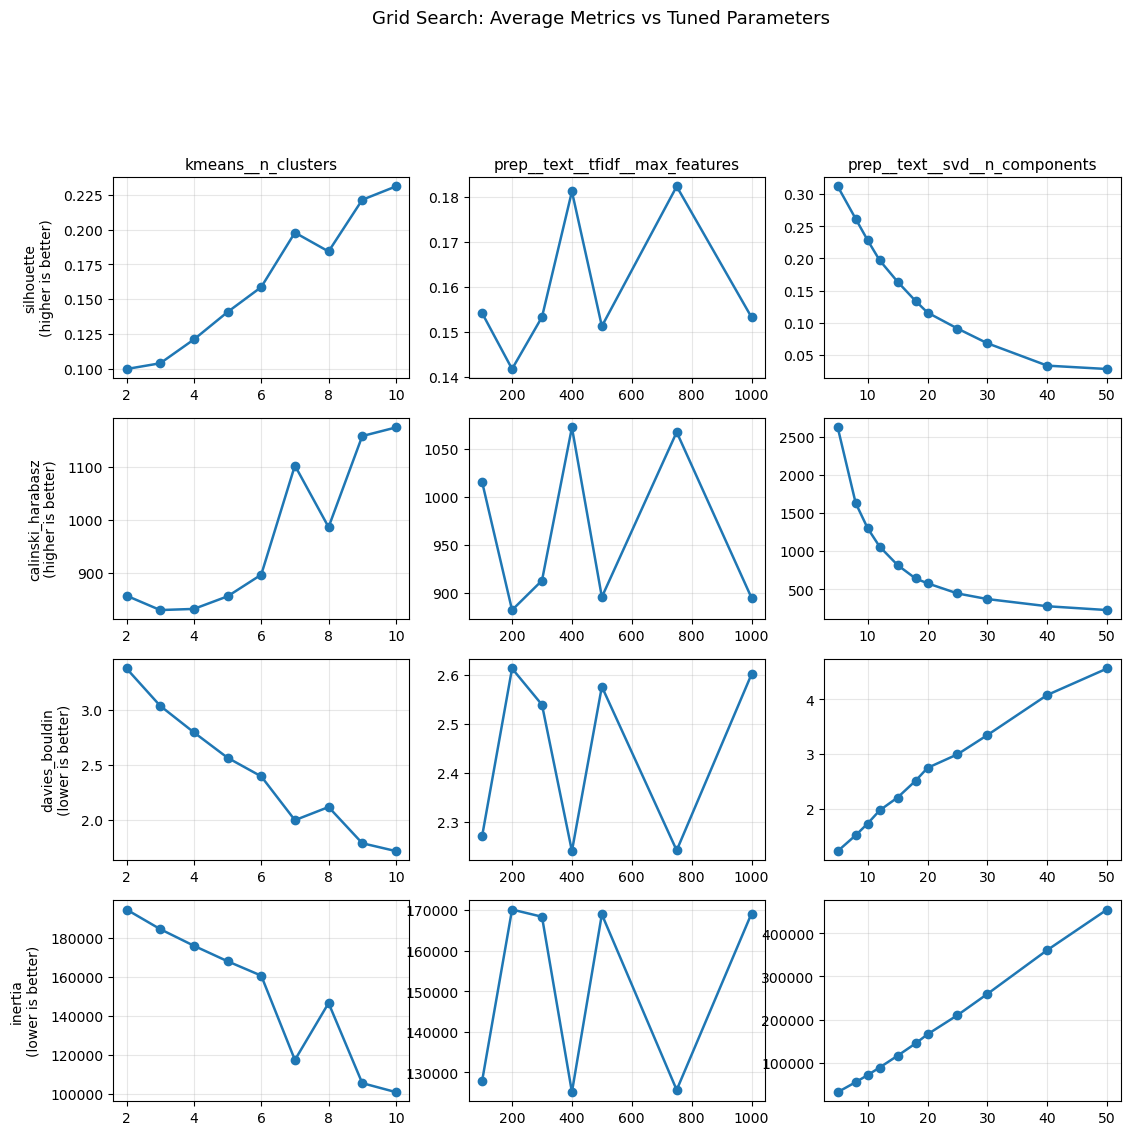



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin


  - 3D plot for metric: inertia




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.01 min
- 3D metric plots: 0.14 min

Total runtime: 0.16 minutes.


In [127]:
# Evaluate all builds results with grid evaluator

grid_evaluator(builds_results, model = 'kmeans')

For new builds, the clustering generally performed better with more clusters and fewer SVD components. Metrics fluctuated substantially as we varied tf-idf feature count, though 400was a good choice.

### Renovations

In [77]:
# Load first renos grid search results

renos_results_list = []

renos_results_01 = read_grid_results_csv('RENOS','01_kmeans_grid_results_renos.csv')

renos_results_list.append(renos_results_01)

examine_df('first renovations results', renos_results_01)



Number of records in the first renovations results is: 80


Number of features in the first renovations results is: 9

The columns in the first renovations results are: Index(['kmeans__n_clusters', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'inertia', 'silhouette',
       'calinski_harabasz', 'davies_bouldin', 'fit_time_s',
       'n_clusters_found'],
      dtype='object')


 Other info about first renovations results:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   kmeans__n_clusters               80 non-null     int64  
 1   prep__text__svd__n_components    80 non-null     int64  
 2   prep__text__tfidf__max_features  80 non-null     int64  
 3   inertia                          80 non-null     float64
 4   silhouette                       80 non-null     float64
 5   c

None


 Basic statistical info about first renovations results:



,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,fit_time_s,n_clusters_found
count,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000
mean,5.000000,25.000000,575.000000,180055.383709,0.108050,483.761749,2.923998,0.816814,5.000000
std,2.012618,11.250879,287.943384,89069.753927,0.063379,317.083651,0.968856,4.393863,2.012618
min,2.000000,10.000000,200.000000,43628.026770,0.019235,171.574585,1.178817,0.090544,2.000000
25%,4.000000,17.500000,425.000000,109856.391560,0.058179,257.712472,2.201817,0.103045,4.000000
50%,5.000000,25.000000,550.000000,180453.196950,0.088542,355.439041,2.863325,0.108060,5.000000
75%,6.000000,32.500000,700.000000,248497.635975,0.143316,603.750054,3.614302,0.119758,6.000000
max,8.000000,40.000000,1000.000000,320982.288300,0.260727,1239.039510,5.358027,28.095127,8.000000




Sample of records in the first renovations results:


,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,fit_time_s,n_clusters_found
0,2,10,200,81121.50950,0.139638,1029.321371,2.571616,0.103619,2
1,2,10,500,81307.44224,0.137190,1008.974077,2.571267,0.102556,2
2,2,10,600,81203.57276,0.138866,1020.324930,2.550627,28.072824,2
3,2,10,1000,81279.61148,0.141299,1012.024207,2.531253,28.095127,2
4,2,20,200,159804.99120,0.070556,525.803213,3.717493,0.158580,2


In [78]:
# Load second renos grid search results

renos_results_02 = read_grid_results_csv('RENOS','02_kmeans_grid_results_renos.csv')

renos_results_list.append(renos_results_02)

examine_df('second renovations results', renos_results_02)



Number of records in the second renovations results is: 567


Number of features in the second renovations results is: 12

The columns in the second renovations results are: Index(['kmeans__n_clusters', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'inertia', 'silhouette',
       'calinski_harabasz', 'davies_bouldin', 'aic', 'bic', 'avg_loglik',
       'fit_time_s', 'n_clusters_found'],
      dtype='object')


 Other info about second renovations results:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   kmeans__n_clusters               567 non-null    int64  
 1   prep__text__svd__n_components    567 non-null    int64  
 2   prep__text__tfidf__max_features  567 non-null    int64  
 3   inertia                          567 non-null    float64
 4   silhouette                

None


 Basic statistical info about second renovations results:



,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
count,567.000000,567.000000,567.000000,567.000000,567.000000,567.000000,567.000000,0.0,0.0,567.000000,567.000000,567.000000
mean,6.000000,15.888889,271.428571,104079.896931,0.159792,865.554108,2.244437,NaN,NaN,-104079.896931,26.787060,6.000000
std,2.584269,7.716029,130.655745,60951.847465,0.079511,652.155161,0.817973,NaN,NaN,60951.847465,0.530435,2.584269
min,2.000000,5.000000,100.000000,12169.439168,0.038731,237.648392,0.790953,NaN,NaN,-238364.738462,19.603602,2.000000
25%,4.000000,10.000000,150.000000,53698.565617,0.091798,426.220229,1.600153,NaN,NaN,-146626.452767,26.602521,4.000000
50%,6.000000,15.000000,250.000000,96492.271536,0.144006,604.308738,2.177839,NaN,NaN,-96492.271536,26.766996,6.000000
75%,8.000000,20.000000,400.000000,146626.452767,0.221599,1094.019425,2.740147,NaN,NaN,-53698.565617,26.928456,8.000000
max,10.000000,30.000000,500.000000,238364.738462,0.383701,3361.342169,4.530604,NaN,NaN,-12169.439168,32.239511,10.000000




Sample of records in the second renovations results:


,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
0,2,5,100,41275.571867,0.239580,2112.818336,1.728800,NaN,NaN,-41275.571867,30.836168,2
1,2,5,150,41579.291374,0.235907,2040.130212,1.751884,NaN,NaN,-41579.291374,27.873468,2
2,2,5,200,41543.450832,0.238468,2048.428996,1.743300,NaN,NaN,-41543.450832,27.406778,2
3,2,5,250,41621.977418,0.233245,2029.711464,1.726849,NaN,NaN,-41621.977418,27.438765,2
4,2,5,300,41550.912303,0.245479,2046.647678,1.664964,NaN,NaN,-41550.912303,27.460034,2


In [79]:
# Load third renos grid search results

renos_results_03 = read_grid_results_csv('RENOS','03_kmeans_grid_results_renos.csv')

renos_results_list.append(renos_results_03)

examine_df('third renovations results', renos_results_03)



Number of records in the third renovations results is: 30


Number of features in the third renovations results is: 12

The columns in the third renovations results are: Index(['kmeans__n_clusters', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'inertia', 'silhouette',
       'calinski_harabasz', 'davies_bouldin', 'aic', 'bic', 'avg_loglik',
       'fit_time_s', 'n_clusters_found'],
      dtype='object')


 Other info about third renovations results:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   kmeans__n_clusters               30 non-null     int64  
 1   prep__text__svd__n_components    30 non-null     int64  
 2   prep__text__tfidf__max_features  30 non-null     int64  
 3   inertia                          30 non-null     float64
 4   silhouette                       

None


 Basic statistical info about third renovations results:



,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
count,30.000000,30.000000,30.0,30.000000,30.000000,30.000000,30.000000,0.0,0.0,30.000000,30.000000,30.000000
mean,6.200000,5.500000,400.0,27807.179255,0.281666,2309.343711,1.267286,NaN,NaN,-27807.179255,29.424017,6.200000
std,2.605035,2.861757,0.0,19477.613351,0.055918,918.789623,0.344927,NaN,NaN,19477.613351,1.072109,2.605035
min,3.000000,2.000000,400.0,5626.868101,0.155917,872.527282,0.860207,NaN,NaN,-74062.311367,28.130741,3.000000
25%,4.000000,3.000000,400.0,12856.717202,0.268172,1535.006416,1.044218,NaN,NaN,-38652.938351,28.427970,4.000000
50%,6.000000,5.000000,400.0,21537.632556,0.299037,2512.156961,1.161733,NaN,NaN,-21537.632556,29.239743,6.000000
75%,8.000000,8.000000,400.0,38652.938351,0.316363,2990.557138,1.295434,NaN,NaN,-12856.717202,30.209559,8.000000
max,10.000000,10.000000,400.0,74062.311367,0.360744,3671.429822,2.153678,NaN,NaN,-5626.868101,32.146215,10.000000




Sample of records in the third renovations results:


,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
0,3,2,400,17008.664333,0.305408,2711.846545,1.238029,NaN,NaN,-17008.664333,30.559053,3
1,3,3,400,21650.499227,0.311399,2718.216276,1.194693,NaN,NaN,-21650.499227,31.065083,3
2,3,4,400,28230.863012,0.276744,2265.122162,1.214400,NaN,NaN,-28230.863012,28.796835,3
3,3,6,400,42257.554717,0.263651,1673.765923,1.470735,NaN,NaN,-42257.554717,29.062522,3
4,3,8,400,59245.450849,0.168427,1111.602829,2.121382,NaN,NaN,-59245.450849,30.360695,3


In [80]:
# Merge vertically (row bind)

renos_results = pd.concat(
    renos_results_list,
    axis=0,          # stack rows
    ignore_index=True  # reset index
)

examine_df('all renovation results', renos_results)



Number of records in the all renovation results is: 677


Number of features in the all renovation results is: 12

The columns in the all renovation results are: Index(['kmeans__n_clusters', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'inertia', 'silhouette',
       'calinski_harabasz', 'davies_bouldin', 'fit_time_s', 'n_clusters_found',
       'aic', 'bic', 'avg_loglik'],
      dtype='object')


 Other info about all renovation results:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 677 entries, 0 to 676
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   kmeans__n_clusters               677 non-null    int64  
 1   prep__text__svd__n_components    677 non-null    int64  
 2   prep__text__tfidf__max_features  677 non-null    int64  
 3   inertia                          677 non-null    float64
 4   silhouette                       677 non-n

None


 Basic statistical info about all renovation results:



,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,fit_time_s,n_clusters_found,aic,bic,avg_loglik
count,677.000000,677.000000,677.000000,677.000000,677.000000,677.000000,677.000000,677.000000,677.000000,0.0,0.0,597.000000
mean,5.890694,16.505170,312.998523,109677.913788,0.159078,884.417179,2.281439,23.835049,5.890694,NaN,NaN,-100247.097048
std,2.542512,8.900937,184.096277,70454.952227,0.082899,716.565891,0.877874,8.598802,2.542512,NaN,NaN,61844.141491
min,2.000000,2.000000,100.000000,5626.868101,0.019235,171.574585,0.790953,0.090544,2.000000,NaN,NaN,-238364.738462
25%,4.000000,10.000000,200.000000,53368.467120,0.088631,404.973696,1.575293,26.520543,4.000000,NaN,NaN,-143731.495278
50%,6.000000,15.000000,250.000000,97513.329897,0.141814,599.418124,2.190267,26.739829,6.000000,NaN,NaN,-90269.462563
75%,8.000000,20.000000,400.000000,155784.975304,0.223062,1094.839896,2.818609,26.930979,8.000000,NaN,NaN,-46928.525406
max,10.000000,40.000000,1000.000000,320982.288300,0.383701,3671.429822,5.358027,32.239511,10.000000,NaN,NaN,-5626.868101




Sample of records in the all renovation results:


,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,fit_time_s,n_clusters_found,aic,bic,avg_loglik
0,2,10,200,81121.50950,0.139638,1029.321371,2.571616,0.103619,2,NaN,NaN,NaN
1,2,10,500,81307.44224,0.137190,1008.974077,2.571267,0.102556,2,NaN,NaN,NaN
2,2,10,600,81203.57276,0.138866,1020.324930,2.550627,28.072824,2,NaN,NaN,NaN
3,2,10,1000,81279.61148,0.141299,1012.024207,2.531253,28.095127,2,NaN,NaN,NaN
4,2,20,200,159804.99120,0.070556,525.803213,3.717493,0.158580,2,NaN,NaN,NaN




Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: silhouette  (higher is better)
  • silhouette=0.3837  | kmeans__n_clusters=6.0, prep__text__svd__n_components=5.0, prep__text__tfidf__max_features=500.0, aic=nan, bic=nan, avg_loglik=-16695.000478536513  | time=0.44 min

Metric: calinski_harabasz  (higher is better)
  • calinski_harabasz=3671.4298  | kmeans__n_clusters=8.0, prep__text__svd__n_components=2.0, prep__text__tfidf__max_features=400.0, aic=nan, bic=nan, avg_loglik=-6732.821332137793  | time=0.51 min

Metric: davies_bouldin  (lower is better)
  • davies_bouldin=0.7910  | kmeans__n_clusters=6.0, prep__text__svd__n_components=5.0, prep__text__tfidf__max_features=500.0, aic=nan, bic=nan, avg_loglik=-16695.000478536513  | time=0.44 min

Metric: inertia  (lower is better)
  • inertia=5626.8681  | kmeans__n_clusters=10.0, prep__text__svd__n_components=2.0, prep__text__tfidf__max_features=400.0, aic=nan, bic=nan, avg_loglik

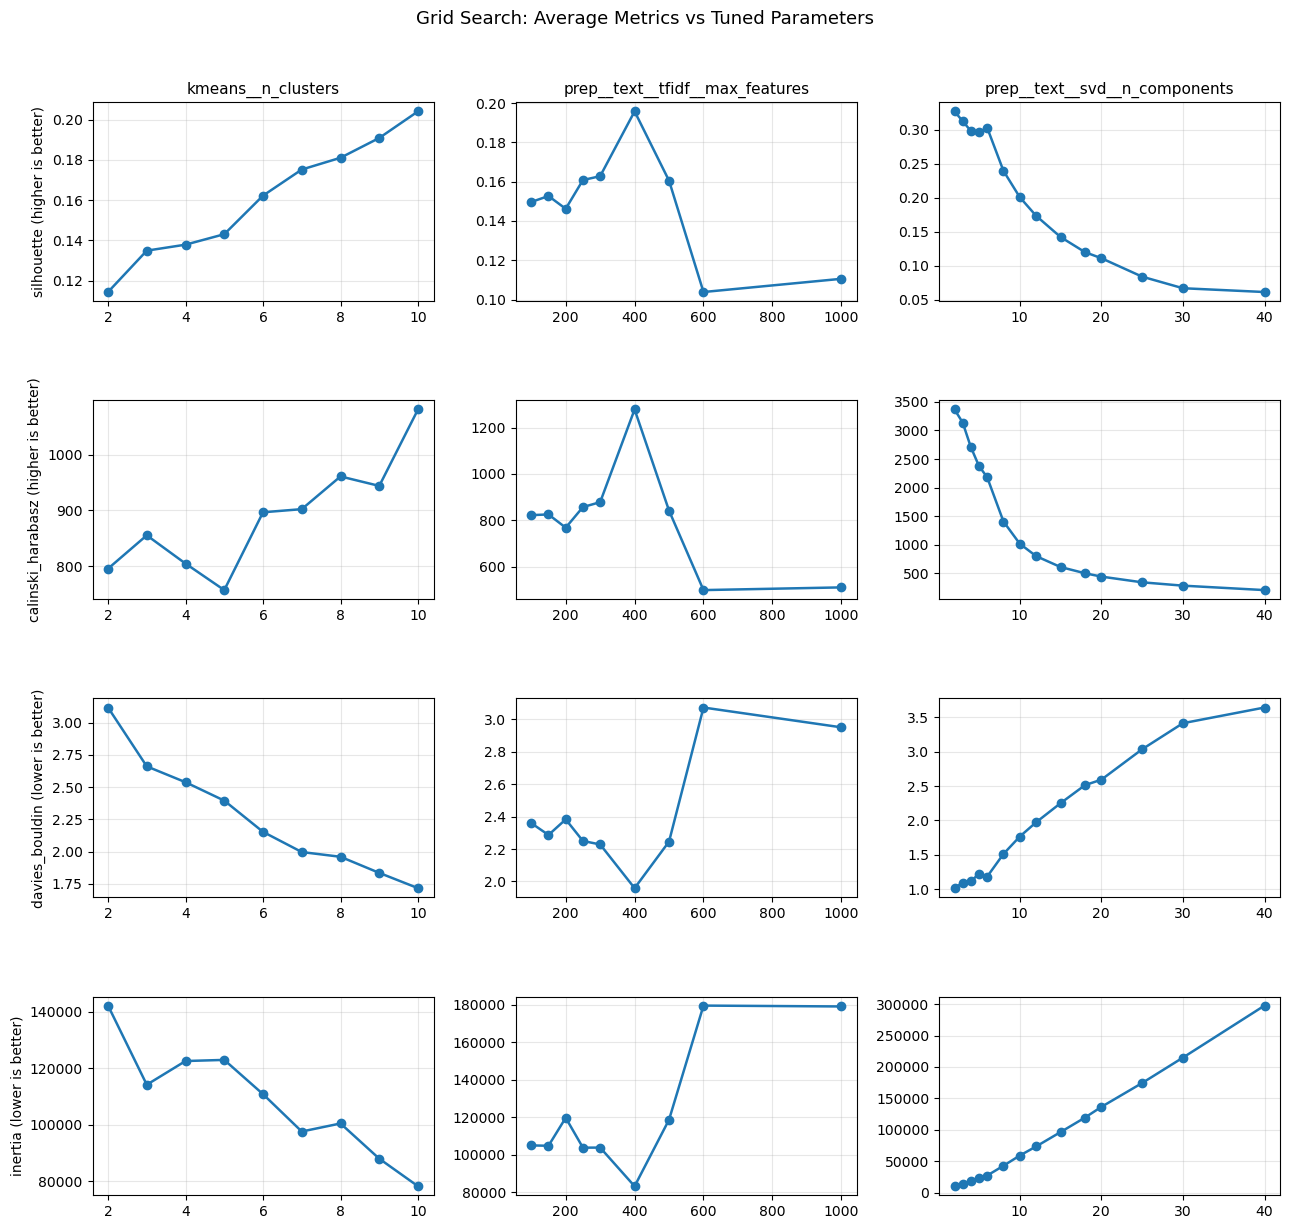



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin


  - 3D plot for metric: inertia




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.01 min
- 3D metric plots: 0.14 min

Total runtime: 0.15 minutes.


In [81]:
# Evaluate all reno results with grid evaluator

grid_evaluator(renos_results)

For renovations, the clustering generally performed better when the number of clusters was higher, the number of SVD components was lower, and the number of tf-idf tokens was below 600.

In [52]:
# Check which combinations have been tested for the renovations dataframe

renos_tested = list_tested_param_combos(renos_results)
display(renos_tested)

617 unique parameter combinations found.


,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,trials
0,2,5,100,1
1,2,5,150,1
2,2,5,200,1
3,2,5,250,1
4,2,5,300,1
...,...,...,...,...
612,10,30,200,1
613,10,30,250,1
614,10,30,300,1
615,10,30,400,1


### Demolitions

In [38]:
# Load first demos grid search results

demos_results_list = []

demos_results_01 = read_grid_results_csv('DEMOS','01_kmeans_grid_results_demos.csv')

demos_results_list.append(demos_results_01)

examine_df('first demo results', demos_results_01)



Number of records in the first demo results is: 36


Number of features in the first demo results is: 9

The columns in the first demo results are: Index(['kmeans__n_clusters', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'inertia', 'silhouette',
       'calinski_harabasz', 'davies_bouldin', 'fit_time_s',
       'n_clusters_found'],
      dtype='object')


 Other info about first demo results:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   kmeans__n_clusters               36 non-null     int64  
 1   prep__text__svd__n_components    36 non-null     int64  
 2   prep__text__tfidf__max_features  36 non-null     int64  
 3   inertia                          36 non-null     float64
 4   silhouette                       36 non-null     float64
 5   calinski_harabasz            

None


 Basic statistical info about first demo results:



,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,fit_time_s,n_clusters_found
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,5.000000,20.000000,433.333333,100505.091423,0.245151,451.658688,1.570817,10.669562,5.000000
std,2.267787,8.280787,172.378321,49322.211302,0.113266,309.570966,0.431469,0.201424,2.267787
min,2.000000,10.000000,200.000000,26615.741081,0.059965,155.855535,0.952870,10.390246,2.000000
25%,3.500000,10.000000,200.000000,56481.473236,0.185685,211.274270,1.252436,10.542382,3.500000
50%,5.000000,20.000000,500.000000,100527.174956,0.236657,324.117884,1.538148,10.625608,5.000000
75%,6.500000,30.000000,600.000000,144978.448291,0.270879,635.982580,1.662965,10.734659,6.500000
max,8.000000,30.000000,600.000000,175011.539953,0.492207,1191.092213,2.487034,11.325707,8.000000




Sample of records in the first demo results:


,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,fit_time_s,n_clusters_found
0,2,10,200,59984.792747,0.175275,525.832227,2.222200,10.427857,2
1,2,10,500,58945.871146,0.211561,635.774086,2.487034,10.479287,2
2,2,10,600,58945.871146,0.211561,635.774086,2.487034,10.390246,2
3,2,20,200,116480.973466,0.235937,302.362110,1.591825,10.681569,2
4,2,20,500,116656.422005,0.236657,293.316649,1.617320,10.524586,2


In [41]:
# Load first demos grid search results

demos_results_02 = read_grid_results_csv('DEMOS','02_kmeans_grid_results_demos.csv')

demos_results_list.append(demos_results_02)

examine_df('second demo results', demos_results_02)



Number of records in the second demo results is: 392


Number of features in the second demo results is: 12

The columns in the second demo results are: Index(['kmeans__n_clusters', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'inertia', 'silhouette',
       'calinski_harabasz', 'davies_bouldin', 'aic', 'bic', 'avg_loglik',
       'fit_time_s', 'n_clusters_found'],
      dtype='object')


 Other info about second demo results:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   kmeans__n_clusters               392 non-null    int64  
 1   prep__text__svd__n_components    392 non-null    int64  
 2   prep__text__tfidf__max_features  392 non-null    int64  
 3   inertia                          392 non-null    float64
 4   silhouette                       392 non-null    float

None


 Basic statistical info about second demo results:



,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,0.0,0.0,392.000000,392.000000,392.000000
mean,7.000000,17.250000,382.857143,73428.280106,0.317067,678.785082,1.471586,NaN,NaN,-73428.280106,10.414671,7.000000
std,2.002556,7.093367,189.731268,41922.279862,0.139134,539.406430,0.359722,NaN,NaN,41922.279862,0.338934,2.002556
min,4.000000,8.000000,180.000000,8535.688657,0.047629,163.896287,0.644512,NaN,NaN,-165532.789936,9.913800,4.000000
25%,5.000000,11.500000,200.000000,36573.145179,0.217354,323.008350,1.215190,NaN,NaN,-102744.141221,10.200462,5.000000
50%,7.000000,16.500000,300.000000,68883.448437,0.308062,472.641626,1.485193,NaN,NaN,-68883.448437,10.391910,7.000000
75%,9.000000,21.250000,600.000000,102744.141221,0.418110,899.582126,1.689835,NaN,NaN,-36573.145179,10.569476,9.000000
max,10.000000,30.000000,700.000000,165532.789936,0.607948,3381.594476,2.532206,NaN,NaN,-8535.688657,13.179427,10.000000




Sample of records in the second demo results:


,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
0,4,8,180,36515.979107,0.257554,915.434297,1.065859,NaN,NaN,-36515.979107,10.311591,4
1,4,8,200,36543.547197,0.299076,913.307846,1.687087,NaN,NaN,-36543.547197,10.542693,4
2,4,8,250,37271.809838,0.312028,858.272833,1.488931,NaN,NaN,-37271.809838,10.575339,4
3,4,8,300,35641.297354,0.317412,984.610359,1.507127,NaN,NaN,-35641.297354,10.458685,4
4,4,8,450,35246.576861,0.365389,1016.951955,1.324304,NaN,NaN,-35246.576861,10.432757,4


In [42]:
# Merge vertically (row bind)

demos_results = pd.concat(
    demos_results_list,
    axis=0,          # stack rows
    ignore_index=True  # reset index
)

examine_df('all demolition results', demos_results)



Number of records in the all demolition results is: 428


Number of features in the all demolition results is: 12

The columns in the all demolition results are: Index(['kmeans__n_clusters', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'inertia', 'silhouette',
       'calinski_harabasz', 'davies_bouldin', 'fit_time_s', 'n_clusters_found',
       'aic', 'bic', 'avg_loglik'],
      dtype='object')


 Other info about all demolition results:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   kmeans__n_clusters               428 non-null    int64  
 1   prep__text__svd__n_components    428 non-null    int64  
 2   prep__text__tfidf__max_features  428 non-null    int64  
 3   inertia                          428 non-null    float64
 4   silhouette                       428 non-n

None


 Basic statistical info about all demolition results:



,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,fit_time_s,n_clusters_found,aic,bic,avg_loglik
count,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,0.0,0.0,392.000000
mean,6.831776,17.481308,387.102804,75705.768908,0.311018,659.680993,1.479933,10.436111,6.831776,NaN,NaN,-73428.280106
std,2.098225,7.230376,188.667256,43189.334728,0.138481,527.510583,0.366757,0.336948,2.098225,NaN,NaN,41922.279862
min,2.000000,8.000000,180.000000,8535.688657,0.047629,155.855535,0.644512,9.913800,2.000000,NaN,NaN,-165532.789936
25%,5.000000,10.000000,200.000000,36925.713295,0.212341,312.899735,1.217775,10.221604,5.000000,NaN,NaN,-102744.141221
50%,7.000000,18.000000,300.000000,71477.642938,0.299601,452.256234,1.492853,10.429053,7.000000,NaN,NaN,-68883.448437
75%,9.000000,25.000000,600.000000,105096.059332,0.410310,883.191966,1.689835,10.590783,9.000000,NaN,NaN,-36573.145179
max,10.000000,30.000000,700.000000,175011.539953,0.607948,3381.594476,2.532206,13.179427,10.000000,NaN,NaN,-8535.688657




Sample of records in the all demolition results:


,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,fit_time_s,n_clusters_found,aic,bic,avg_loglik
0,2,10,200,59984.792747,0.175275,525.832227,2.222200,10.427857,2,NaN,NaN,NaN
1,2,10,500,58945.871146,0.211561,635.774086,2.487034,10.479287,2,NaN,NaN,NaN
2,2,10,600,58945.871146,0.211561,635.774086,2.487034,10.390246,2,NaN,NaN,NaN
3,2,20,200,116480.973466,0.235937,302.362110,1.591825,10.681569,2,NaN,NaN,NaN
4,2,20,500,116656.422005,0.236657,293.316649,1.617320,10.524586,2,NaN,NaN,NaN




Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: silhouette  (higher is better)
  • silhouette=0.6079  | kmeans__n_clusters=10.0, prep__text__svd__n_components=8.0, prep__text__tfidf__max_features=180.0, aic=nan, bic=nan, avg_loglik=-8535.688657496785  | time=0.17 min

Metric: calinski_harabasz  (higher is better)
  • calinski_harabasz=3381.5945  | kmeans__n_clusters=10.0, prep__text__svd__n_components=8.0, prep__text__tfidf__max_features=180.0, aic=nan, bic=nan, avg_loglik=-8535.688657496785  | time=0.17 min

Metric: davies_bouldin  (lower is better)
  • davies_bouldin=0.6445  | kmeans__n_clusters=10.0, prep__text__svd__n_components=8.0, prep__text__tfidf__max_features=300.0, aic=nan, bic=nan, avg_loglik=-8891.855078188924  | time=0.17 min

Metric: inertia  (lower is better)
  • inertia=8535.6887  | kmeans__n_clusters=10.0, prep__text__svd__n_components=8.0, prep__text__tfidf__max_features=180.0, aic=nan, bic=nan, avg_logli

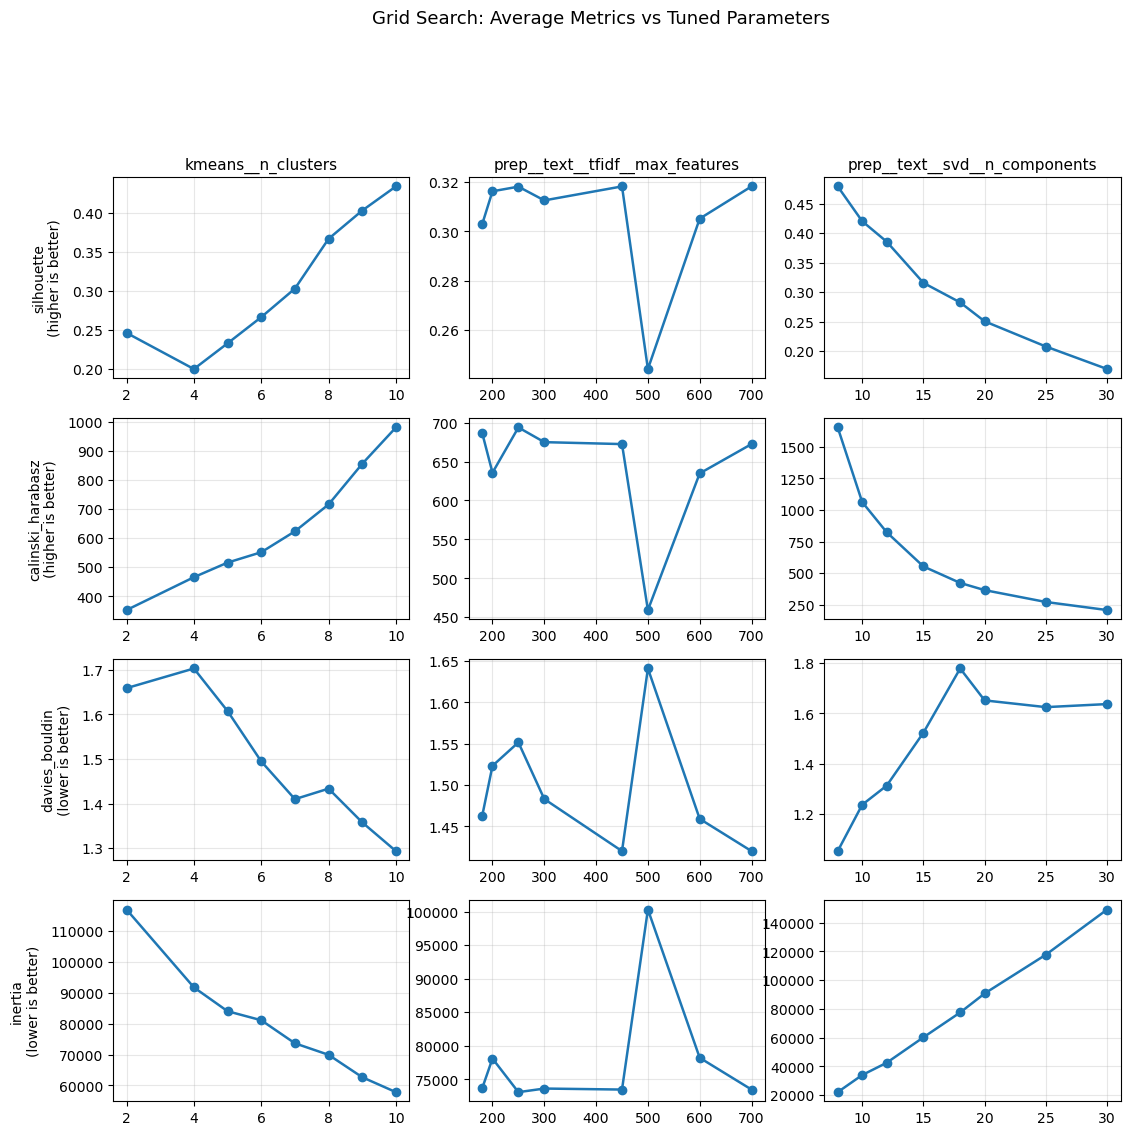



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin


  - 3D plot for metric: inertia




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.01 min
- 3D metric plots: 0.14 min

Total runtime: 0.15 minutes.


In [126]:
# Evaluate all demo results with grid evaluator

grid_evaluator(demos_results)

Our initial two grid searches indicate results are better when the number of clusters is high and the number of SVD components is low. There is a less of clear pattern when it comes to the number of tf-idf tokens selected.

In [99]:
# Check which combinations have been tested for the demolitions dataframe

demos_tested = list_tested_param_combos(demos_results, model = 'kmeans')

examine_df('Kmeans configs tested for demos', demos_tested)

410 unique parameter combinations found.


Number of records in the Kmeans configs tested for demos is: 410


Number of features in the Kmeans configs tested for demos is: 4

The columns in the Kmeans configs tested for demos are: Index(['kmeans__n_clusters', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'trials'],
      dtype='object')


 Other info about Kmeans configs tested for demos:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 4 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   kmeans__n_clusters               410 non-null    int64
 1   prep__text__svd__n_components    410 non-null    int64
 2   prep__text__tfidf__max_features  410 non-null    int64
 3   trials                           410 non-null    int64
dtypes: int64(4)
memory usage: 12.9 KB


None


 Basic statistical info about Kmeans configs tested for demos:



,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,trials
count,410.000000,410.000000,410.000000,410.000000
mean,6.868293,17.370732,386.536585,1.043902
std,2.108829,7.166147,188.132516,0.205128
min,2.000000,8.000000,180.000000,1.000000
25%,5.000000,10.000000,200.000000,1.000000
50%,7.000000,18.000000,300.000000,1.000000
75%,9.000000,25.000000,600.000000,1.000000
max,10.000000,30.000000,700.000000,2.000000




Sample of records in the Kmeans configs tested for demos:


,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,trials
0,2,10,200,1
1,2,10,500,1
2,2,10,600,1
3,2,20,200,1
4,2,20,500,1


## Gaussian Mixture Models Grid Searches

### Builds

In [131]:
# Load first builds GMM grid search results

gmm_builds_results_list = []

gmm_builds_results_01 = read_grid_results_csv('BUILDS','01_gmm_grid_results_builds.csv')

gmm_builds_results_list.append(gmm_builds_results_01)

examine_df('first builds results from GMM', gmm_builds_results_01)



Number of records in the first builds results from GMM is: 24


Number of features in the first builds results from GMM is: 15

The columns in the first builds results from GMM are: Index(['gmm__covariance_type', 'gmm__n_components', 'gmm__n_init',
       'gmm__reg_covar', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'inertia', 'silhouette',
       'calinski_harabasz', 'davies_bouldin', 'aic', 'bic', 'avg_loglik',
       'fit_time_s', 'n_clusters_found'],
      dtype='object')


 Other info about first builds results from GMM:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   gmm__covariance_type             24 non-null     object 
 1   gmm__n_components                24 non-null     int64  
 2   gmm__n_init                      24 non-null     int64  
 3   gmm__reg_covar  

None


 Basic statistical info about first builds results from GMM:



,gmm__n_components,gmm__n_init,gmm__reg_covar,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
count,24.000000,24.0,24.000000,24.00000,24.0,0.0,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,5.000000,3.0,0.000051,7.50000,400.0,NaN,0.153256,1159.137473,1.995427,-527348.591393,-523044.708274,27.924323,63.152948,5.000000
std,1.668115,0.0,0.000051,2.55377,0.0,NaN,0.036148,169.040938,0.205167,196400.635906,195424.347251,10.391239,2.180883,1.668115
min,3.000000,3.0,0.000001,5.00000,400.0,NaN,0.069602,826.866358,1.627145,-849477.282212,-841821.164278,11.199628,59.307856,3.000000
25%,3.000000,3.0,0.000001,5.00000,400.0,NaN,0.128806,1036.714416,1.866009,-705100.714600,-703197.417992,18.581649,61.106430,3.000000
50%,5.000000,3.0,0.000051,7.50000,400.0,NaN,0.167170,1192.217221,2.019659,-512050.438136,-507764.443143,27.115830,63.606086,5.000000
75%,7.000000,3.0,0.000100,10.00000,400.0,NaN,0.175061,1307.791489,2.096523,-349667.446830,-342347.625665,37.279835,64.975551,7.000000
max,7.000000,3.0,0.000100,10.00000,400.0,NaN,0.205605,1384.881893,2.383954,-211730.552591,-210814.680539,44.992460,66.357681,7.000000




Sample of records in the first builds results from GMM:


,gmm__covariance_type,gmm__n_components,gmm__n_init,gmm__reg_covar,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
0,diag,3,3,0.000001,5,400,NaN,0.177557,1336.964103,1.868634,-543188.632283,-542487.417743,28.707979,60.015059,3
1,diag,3,3,0.000001,10,400,NaN,0.173466,1304.686513,2.089568,-492343.818812,-491427.946760,26.024927,63.903039,3
2,diag,3,3,0.000100,5,400,NaN,0.175770,1341.271326,1.881222,-266986.163850,-266284.949311,14.115710,62.938251,3
3,diag,3,3,0.000100,10,400,NaN,0.173388,1303.894696,2.090159,-211730.552591,-210814.680539,11.199628,60.305855,3
4,diag,5,3,0.000001,5,400,NaN,0.116648,1238.139375,1.627145,-709016.865872,-707843.404805,37.475954,60.256284,5


In [132]:
# Load second builds GMM grid search results

gmm_builds_results_02 = read_grid_results_csv('BUILDS','02_gmm_grid_results_builds.csv')

gmm_builds_results_list.append(gmm_builds_results_02)

examine_df('first builds results from GMM', gmm_builds_results_02)



Number of records in the first builds results from GMM is: 84


Number of features in the first builds results from GMM is: 15

The columns in the first builds results from GMM are: Index(['gmm__covariance_type', 'gmm__n_components', 'gmm__n_init',
       'gmm__reg_covar', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'inertia', 'silhouette',
       'calinski_harabasz', 'davies_bouldin', 'aic', 'bic', 'avg_loglik',
       'fit_time_s', 'n_clusters_found'],
      dtype='object')


 Other info about first builds results from GMM:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   gmm__covariance_type             84 non-null     object 
 1   gmm__n_components                84 non-null     int64  
 2   gmm__n_init                      84 non-null     int64  
 3   gmm__reg_covar  

None


 Basic statistical info about first builds results from GMM:



,gmm__n_components,gmm__n_init,gmm__reg_covar,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
count,84.000000,84.0,8.400000e+01,84.00000,84.000000,0.0,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000
mean,6.142857,3.0,1.000000e-04,9.50000,350.000000,NaN,0.171398,1184.302870,2.051239,-407231.503729,-395730.120154,21.684611,57.071007,6.142857
std,2.244902,0.0,5.453570e-20,6.35591,50.300303,NaN,0.053510,489.498019,0.559218,120718.547607,124794.825219,6.321543,2.034043,2.244902
min,3.000000,3.0,1.000000e-04,2.00000,300.000000,NaN,0.066268,378.769316,1.217276,-636041.345371,-628535.487695,6.581233,55.160277,3.000000
25%,4.000000,3.0,1.000000e-04,4.00000,300.000000,NaN,0.129518,729.190324,1.614006,-490891.390909,-485191.466247,17.184068,56.154311,4.000000
50%,6.000000,3.0,1.000000e-04,8.00000,350.000000,NaN,0.172431,1187.718704,1.879081,-429965.583171,-423902.439507,22.823311,56.637485,6.000000
75%,8.000000,3.0,1.000000e-04,15.00000,400.000000,NaN,0.206984,1569.258250,2.440438,-320697.595660,-303800.471827,26.020070,57.299024,8.000000
max,10.000000,3.0,1.000000e-04,20.00000,400.000000,NaN,0.275440,2157.585595,3.599880,-121403.576576,-110076.815184,33.714040,69.385493,10.000000




Sample of records in the first builds results from GMM:


,gmm__covariance_type,gmm__n_components,gmm__n_init,gmm__reg_covar,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
0,full,3,3,0.0001,2,300,NaN,0.163149,1319.233710,2.056300,-464708.520194,-462461.771567,24.584558,60.128819,3
1,full,3,3,0.0001,2,400,NaN,0.196007,1608.853822,1.728393,-428420.995755,-426174.247127,22.667424,58.200919,3
2,full,3,3,0.0001,4,300,NaN,0.256010,1987.722061,1.521873,-433375.069974,-430462.883059,22.938983,58.014789,3
3,full,3,3,0.0001,4,400,NaN,0.256679,1984.426104,1.517863,-433697.150136,-430784.963221,22.955999,63.308901,3
4,full,3,3,0.0001,6,300,NaN,0.189885,1434.614946,1.825926,-402815.166525,-399151.678318,21.335543,62.575083,3


In [133]:
# Merge vertically (row bind)

gmm_builds_results = pd.concat(
    gmm_builds_results_list,
    axis=0,          # stack rows
    ignore_index=True  # reset index
)

examine_df('all GMM builds results', gmm_builds_results)



Number of records in the all GMM builds results is: 108


Number of features in the all GMM builds results is: 15

The columns in the all GMM builds results are: Index(['gmm__covariance_type', 'gmm__n_components', 'gmm__n_init',
       'gmm__reg_covar', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'inertia', 'silhouette',
       'calinski_harabasz', 'davies_bouldin', 'aic', 'bic', 'avg_loglik',
       'fit_time_s', 'n_clusters_found'],
      dtype='object')


 Other info about all GMM builds results:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   gmm__covariance_type             108 non-null    object 
 1   gmm__n_components                108 non-null    int64  
 2   gmm__n_init                      108 non-null    int64  
 3   gmm__reg_covar                   108 non-

None


 Basic statistical info about all GMM builds results:



,gmm__n_components,gmm__n_init,gmm__reg_covar,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
count,108.000000,108.0,108.000000,108.000000,108.000000,0.0,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000
mean,5.888889,3.0,0.000089,9.055556,361.111111,NaN,0.167367,1178.710560,2.038836,-433924.189877,-424022.250848,23.071214,58.422550,5.888889
std,2.176052,0.0,0.000031,5.782399,48.977075,NaN,0.050590,438.311678,0.502168,148703.586360,152044.470098,7.810308,3.268759,2.176052
min,3.000000,3.0,0.000001,2.000000,300.000000,NaN,0.066268,378.769316,1.217276,-849477.282212,-841821.164278,6.581233,55.160277,3.000000
25%,4.000000,3.0,0.000100,4.000000,300.000000,NaN,0.129518,860.449060,1.654910,-524056.411978,-513587.893830,17.192550,56.222846,4.000000
50%,6.000000,3.0,0.000100,8.000000,400.000000,NaN,0.169589,1187.718704,1.911823,-436912.524862,-430514.509590,23.160482,57.026191,6.000000
75%,7.000000,3.0,0.000100,15.000000,400.000000,NaN,0.199276,1444.388938,2.276943,-322805.516724,-314123.403288,27.807344,60.021717,7.000000
max,10.000000,3.0,0.000100,20.000000,400.000000,NaN,0.275440,2157.585595,3.599880,-121403.576576,-110076.815184,44.992460,69.385493,10.000000




Sample of records in the all GMM builds results:


,gmm__covariance_type,gmm__n_components,gmm__n_init,gmm__reg_covar,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
0,diag,3,3,0.000001,5,400,NaN,0.177557,1336.964103,1.868634,-543188.632283,-542487.417743,28.707979,60.015059,3
1,diag,3,3,0.000001,10,400,NaN,0.173466,1304.686513,2.089568,-492343.818812,-491427.946760,26.024927,63.903039,3
2,diag,3,3,0.000100,5,400,NaN,0.175770,1341.271326,1.881222,-266986.163850,-266284.949311,14.115710,62.938251,3
3,diag,3,3,0.000100,10,400,NaN,0.173388,1303.894696,2.090159,-211730.552591,-210814.680539,11.199628,60.305855,3
4,diag,5,3,0.000001,5,400,NaN,0.116648,1238.139375,1.627145,-709016.865872,-707843.404805,37.475954,60.256284,5


In [96]:
# Check which GMM combinations have been tested for the builds dataframe

gmm_builds_tested = list_tested_param_combos(gmm_builds_results, model = 'gmm')

examine_df('GMM configurations tested for builds', gmm_builds_tested)

24 unique parameter combinations found.


Number of records in the GMM configurations tested for builds is: 24


Number of features in the GMM configurations tested for builds is: 7

The columns in the GMM configurations tested for builds are: Index(['gmm__n_components', 'gmm__covariance_type', 'gmm__reg_covar',
       'gmm__n_init', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'trials'],
      dtype='object')


 Other info about GMM configurations tested for builds:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   gmm__n_components                24 non-null     int64  
 1   gmm__covariance_type             24 non-null     object 
 2   gmm__reg_covar                   24 non-null     float64
 3   gmm__n_init                      24 non-null     int64  
 4   prep__text__svd__n

None


 Basic statistical info about GMM configurations tested for builds:



,gmm__n_components,gmm__reg_covar,gmm__n_init,prep__text__svd__n_components,prep__text__tfidf__max_features,trials
count,24.000000,24.000000,24.0,24.00000,24.0,24.0
mean,5.000000,0.000051,3.0,7.50000,400.0,1.0
std,1.668115,0.000051,0.0,2.55377,0.0,0.0
min,3.000000,0.000001,3.0,5.00000,400.0,1.0
25%,3.000000,0.000001,3.0,5.00000,400.0,1.0
50%,5.000000,0.000051,3.0,7.50000,400.0,1.0
75%,7.000000,0.000100,3.0,10.00000,400.0,1.0
max,7.000000,0.000100,3.0,10.00000,400.0,1.0




Sample of records in the GMM configurations tested for builds:


,gmm__n_components,gmm__covariance_type,gmm__reg_covar,gmm__n_init,prep__text__svd__n_components,prep__text__tfidf__max_features,trials
0,3,diag,0.000001,3,5,400,1
1,3,diag,0.000001,3,10,400,1
2,3,diag,0.000100,3,5,400,1
3,3,diag,0.000100,3,10,400,1
4,3,full,0.000001,3,5,400,1


In [107]:
# Test print top configurations function for GMM

print_top_configs(gmm_builds_results, model = 'gmm')


=== Top parameter configurations by metric ===

Metric: bic  (lower is better)
  • bic=-841821.1643  | gmm__covariance_type=full, gmm__n_components=7, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=5, prep__text__tfidf__max_features=400, inertia=nan  | time=1.06 min

Metric: aic  (lower is better)
  • aic=-849477.2822  | gmm__covariance_type=full, gmm__n_components=7, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=5, prep__text__tfidf__max_features=400, inertia=nan  | time=1.06 min

Metric: avg_loglik  (higher is better)
  • avg_loglik=44.9925  | gmm__covariance_type=full, gmm__n_components=7, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=5, prep__text__tfidf__max_features=400, inertia=nan  | time=1.06 min

Metric: silhouette  (higher is better)
  • silhouette=0.2056  | gmm__covariance_type=full, gmm__n_components=7, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__svd__n_components=10, prep__text__tfidf__max_features=400, 

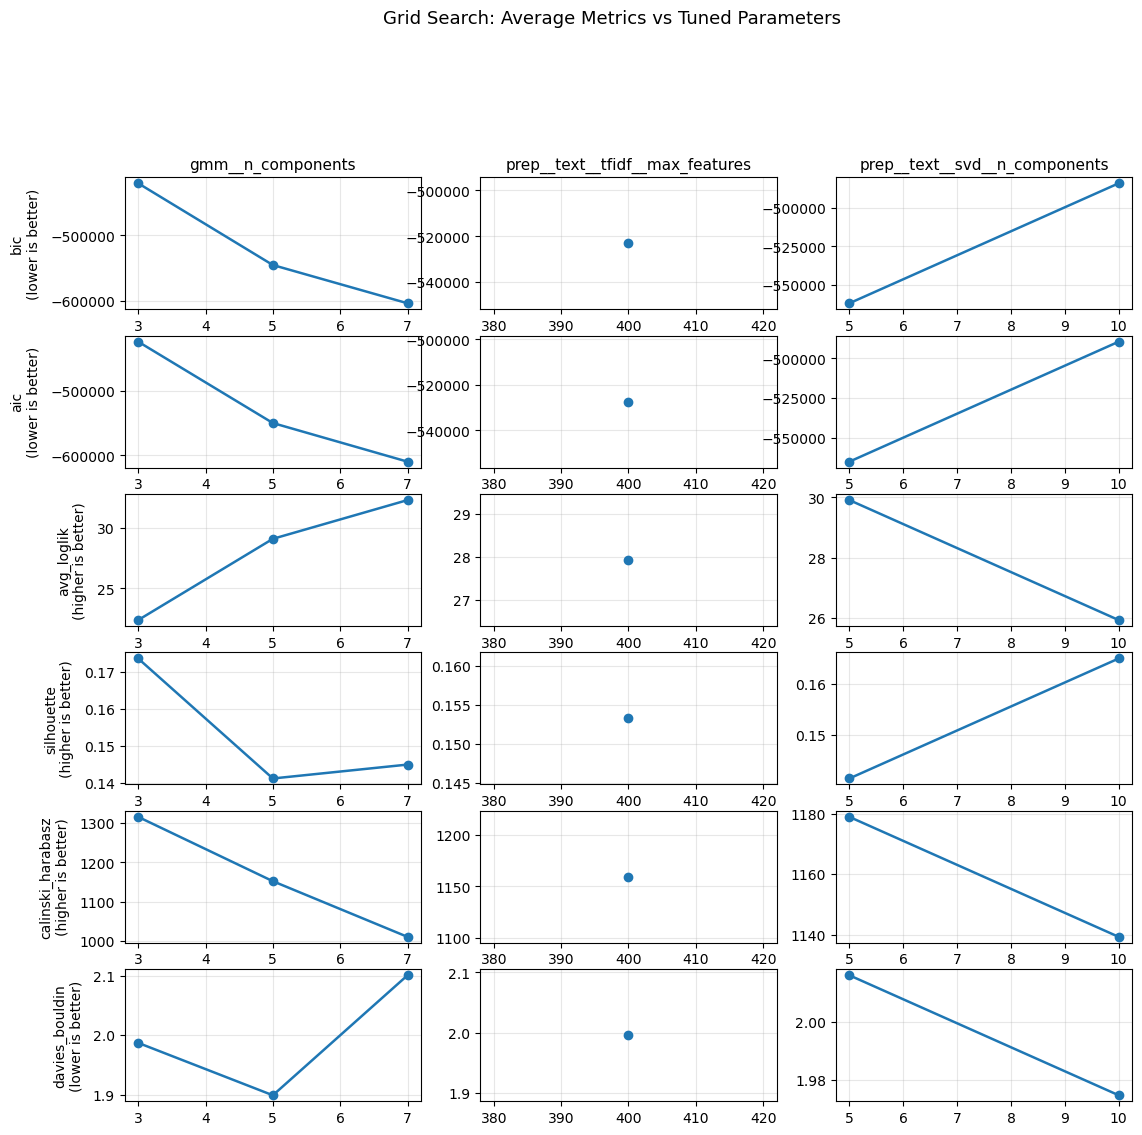

In [120]:
# Test function to plot metric trends with GMM

plot_metric_trends(gmm_builds_results, model = 'gmm')

In [121]:
# Test function to plot 3D Grid Search visualization

plot_grid_3d_metric(gmm_builds_results, metric = 'silhouette', model = 'gmm')



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: bic  (lower is better)
  • bic=-841821.1643  | gmm__covariance_type=full, gmm__n_components=7, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=5, prep__text__tfidf__max_features=400, inertia=nan  | time=1.06 min

Metric: aic  (lower is better)
  • aic=-849477.2822  | gmm__covariance_type=full, gmm__n_components=7, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=5, prep__text__tfidf__max_features=400, inertia=nan  | time=1.06 min

Metric: avg_loglik  (higher is better)
  • avg_loglik=44.9925  | gmm__covariance_type=full, gmm__n_components=7, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=5, prep__text__tfidf__max_features=400, inertia=nan  | time=1.06 min

Metric: silhouette  (higher is better)
  • silhouette=0.2754  | gmm__covariance_type=full, gmm__n_components=4, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__svd__

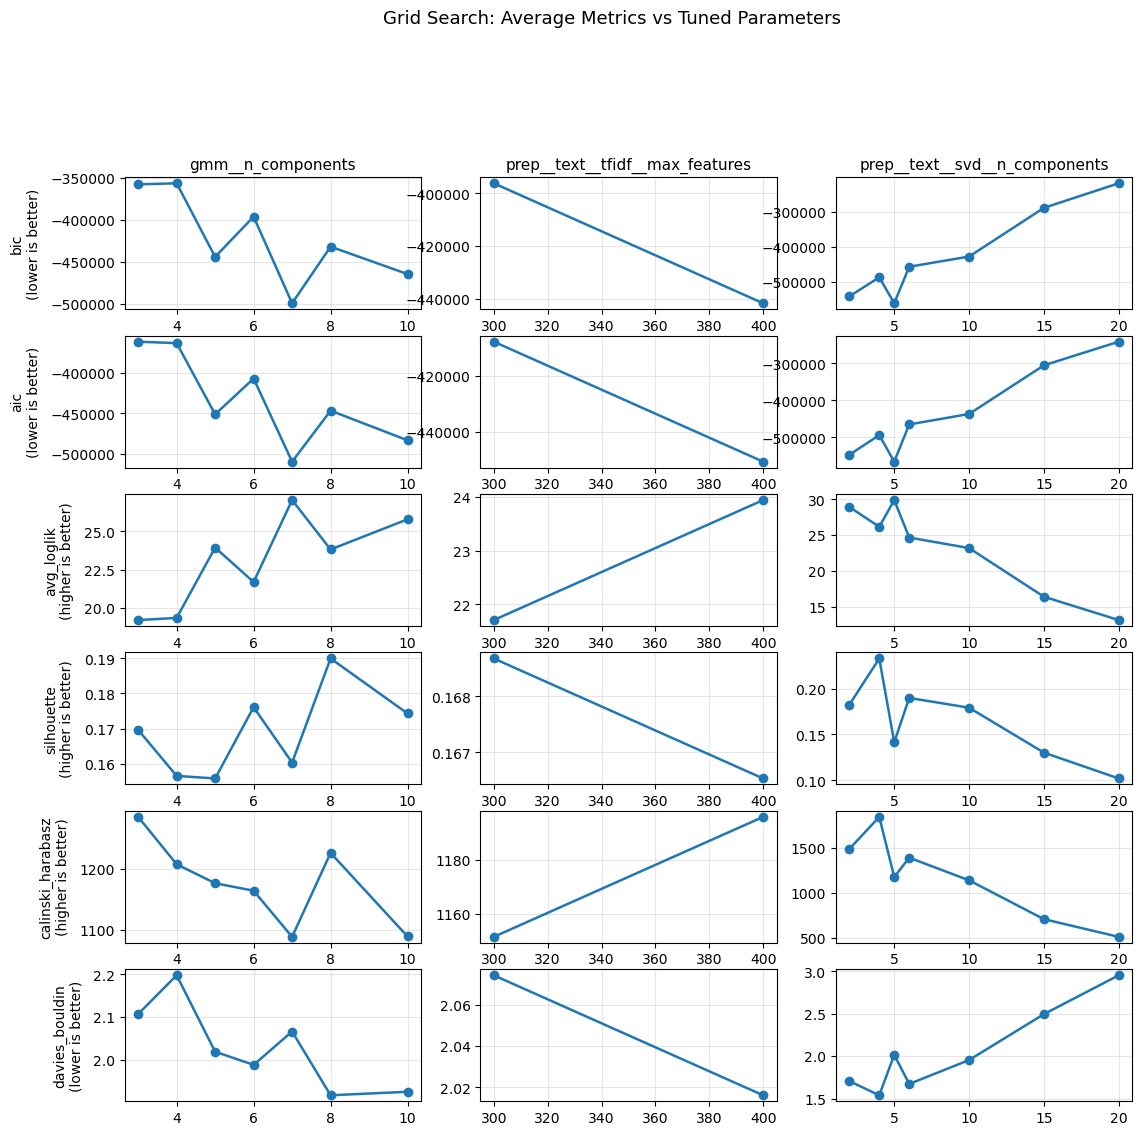



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: bic


  - 3D plot for metric: aic


  - 3D plot for metric: avg_loglik


  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.02 min
- 3D metric plots: 0.21 min

Total runtime: 0.23 minutes.


In [134]:
# Test full grid evaluator

grid_evaluator(gmm_builds_results, model = 'gmm')

### Renovations

In [128]:
# Load first builds GMM grid search results

gmm_renos_results_list = []

gmm_renos_results_01 = read_grid_results_csv('RENOS','01_gmm_grid_results_renos.csv')

gmm_renos_results_list.append(gmm_renos_results_01)

examine_df('first renos results from GMM', gmm_renos_results_01)



Number of records in the first renos results from GMM is: 120


Number of features in the first renos results from GMM is: 15

The columns in the first renos results from GMM are: Index(['gmm__covariance_type', 'gmm__n_components', 'gmm__n_init',
       'gmm__reg_covar', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'inertia', 'silhouette',
       'calinski_harabasz', 'davies_bouldin', 'aic', 'bic', 'avg_loglik',
       'fit_time_s', 'n_clusters_found'],
      dtype='object')


 Other info about first renos results from GMM:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   gmm__covariance_type             120 non-null    object 
 1   gmm__n_components                120 non-null    int64  
 2   gmm__n_init                      120 non-null    int64  
 3   gmm__reg_covar   

None


 Basic statistical info about first renos results from GMM:



,gmm__n_components,gmm__n_init,gmm__reg_covar,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
count,120.000000,120.0,120.000000,120.00000,120.0,0.0,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,5.166667,3.0,0.000051,8.40000,500.0,NaN,0.180751,994.896367,2.424679,-303999.508880,-299781.433987,19.378388,29.868199,5.166667
std,2.683073,0.0,0.000050,6.40168,0.0,NaN,0.086038,571.677485,0.950002,193620.455971,193966.615502,12.289004,1.053310,2.683073
min,2.000000,3.0,0.000001,2.00000,500.0,NaN,0.018037,217.756724,1.231370,-665668.156575,-664071.694877,-14.368440,27.804810,2.000000
25%,3.000000,3.0,0.000001,4.00000,500.0,NaN,0.108469,577.243807,1.820018,-438022.430966,-436889.570590,11.938540,29.180595,3.000000
50%,4.500000,3.0,0.000051,6.00000,500.0,NaN,0.198254,931.748314,2.203078,-308656.174174,-307244.455860,19.622932,29.729577,4.500000
75%,7.000000,3.0,0.000100,10.00000,500.0,NaN,0.232521,1291.820141,2.811403,-187672.507684,-185431.636623,27.831583,30.374313,7.000000
max,10.000000,3.0,0.000100,20.00000,500.0,NaN,0.341364,2737.607850,5.390993,226536.933434,227352.592904,42.293724,33.740045,10.000000




Sample of records in the first renos results from GMM:


,gmm__covariance_type,gmm__n_components,gmm__n_init,gmm__reg_covar,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
0,diag,2,3,0.000001,2,500,NaN,0.314283,2734.706673,1.327308,-316796.669031,-316482.953850,20.119789,31.975614,2
1,diag,2,3,0.000001,4,500,NaN,0.227511,1794.216913,1.740353,-273038.948806,-272669.462037,17.342536,28.721959,2
2,diag,2,3,0.000001,6,500,NaN,0.198254,1475.127739,1.971970,-230617.689567,-230192.431211,14.650139,30.365358,2
3,diag,2,3,0.000001,10,500,NaN,0.119798,931.748314,2.613500,-144434.345580,-143897.544049,9.180212,29.610091,2
4,diag,2,3,0.000001,20,500,NaN,0.044061,387.271750,3.839515,93412.097249,94227.756720,-5.916070,30.401176,2


In [129]:
# Merge vertically (row bind)

gmm_renos_results = pd.concat(
    gmm_renos_results_list,
    axis=0,          # stack rows
    ignore_index=True  # reset index
)

examine_df('all GMM renos results', gmm_renos_results)



Number of records in the all GMM renos results is: 120


Number of features in the all GMM renos results is: 15

The columns in the all GMM renos results are: Index(['gmm__covariance_type', 'gmm__n_components', 'gmm__n_init',
       'gmm__reg_covar', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'inertia', 'silhouette',
       'calinski_harabasz', 'davies_bouldin', 'aic', 'bic', 'avg_loglik',
       'fit_time_s', 'n_clusters_found'],
      dtype='object')


 Other info about all GMM renos results:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   gmm__covariance_type             120 non-null    object 
 1   gmm__n_components                120 non-null    int64  
 2   gmm__n_init                      120 non-null    int64  
 3   gmm__reg_covar                   120 non-null

None


 Basic statistical info about all GMM renos results:



,gmm__n_components,gmm__n_init,gmm__reg_covar,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
count,120.000000,120.0,120.000000,120.00000,120.0,0.0,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,5.166667,3.0,0.000051,8.40000,500.0,NaN,0.180751,994.896367,2.424679,-303999.508880,-299781.433987,19.378388,29.868199,5.166667
std,2.683073,0.0,0.000050,6.40168,0.0,NaN,0.086038,571.677485,0.950002,193620.455971,193966.615502,12.289004,1.053310,2.683073
min,2.000000,3.0,0.000001,2.00000,500.0,NaN,0.018037,217.756724,1.231370,-665668.156575,-664071.694877,-14.368440,27.804810,2.000000
25%,3.000000,3.0,0.000001,4.00000,500.0,NaN,0.108469,577.243807,1.820018,-438022.430966,-436889.570590,11.938540,29.180595,3.000000
50%,4.500000,3.0,0.000051,6.00000,500.0,NaN,0.198254,931.748314,2.203078,-308656.174174,-307244.455860,19.622932,29.729577,4.500000
75%,7.000000,3.0,0.000100,10.00000,500.0,NaN,0.232521,1291.820141,2.811403,-187672.507684,-185431.636623,27.831583,30.374313,7.000000
max,10.000000,3.0,0.000100,20.00000,500.0,NaN,0.341364,2737.607850,5.390993,226536.933434,227352.592904,42.293724,33.740045,10.000000




Sample of records in the all GMM renos results:


,gmm__covariance_type,gmm__n_components,gmm__n_init,gmm__reg_covar,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
0,diag,2,3,0.000001,2,500,NaN,0.314283,2734.706673,1.327308,-316796.669031,-316482.953850,20.119789,31.975614,2
1,diag,2,3,0.000001,4,500,NaN,0.227511,1794.216913,1.740353,-273038.948806,-272669.462037,17.342536,28.721959,2
2,diag,2,3,0.000001,6,500,NaN,0.198254,1475.127739,1.971970,-230617.689567,-230192.431211,14.650139,30.365358,2
3,diag,2,3,0.000001,10,500,NaN,0.119798,931.748314,2.613500,-144434.345580,-143897.544049,9.180212,29.610091,2
4,diag,2,3,0.000001,20,500,NaN,0.044061,387.271750,3.839515,93412.097249,94227.756720,-5.916070,30.401176,2




Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: bic  (lower is better)
  • bic=-664071.6949  | gmm__covariance_type=diag, gmm__n_components=10, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=2, prep__text__tfidf__max_features=500, inertia=nan  | time=0.51 min

Metric: aic  (lower is better)
  • aic=-665668.1566  | gmm__covariance_type=diag, gmm__n_components=10, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=2, prep__text__tfidf__max_features=500, inertia=nan  | time=0.51 min

Metric: avg_loglik  (higher is better)
  • avg_loglik=42.2937  | gmm__covariance_type=diag, gmm__n_components=10, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=2, prep__text__tfidf__max_features=500, inertia=nan  | time=0.51 min

Metric: silhouette  (higher is better)
  • silhouette=0.3414  | gmm__covariance_type=full, gmm__n_components=5, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__sv

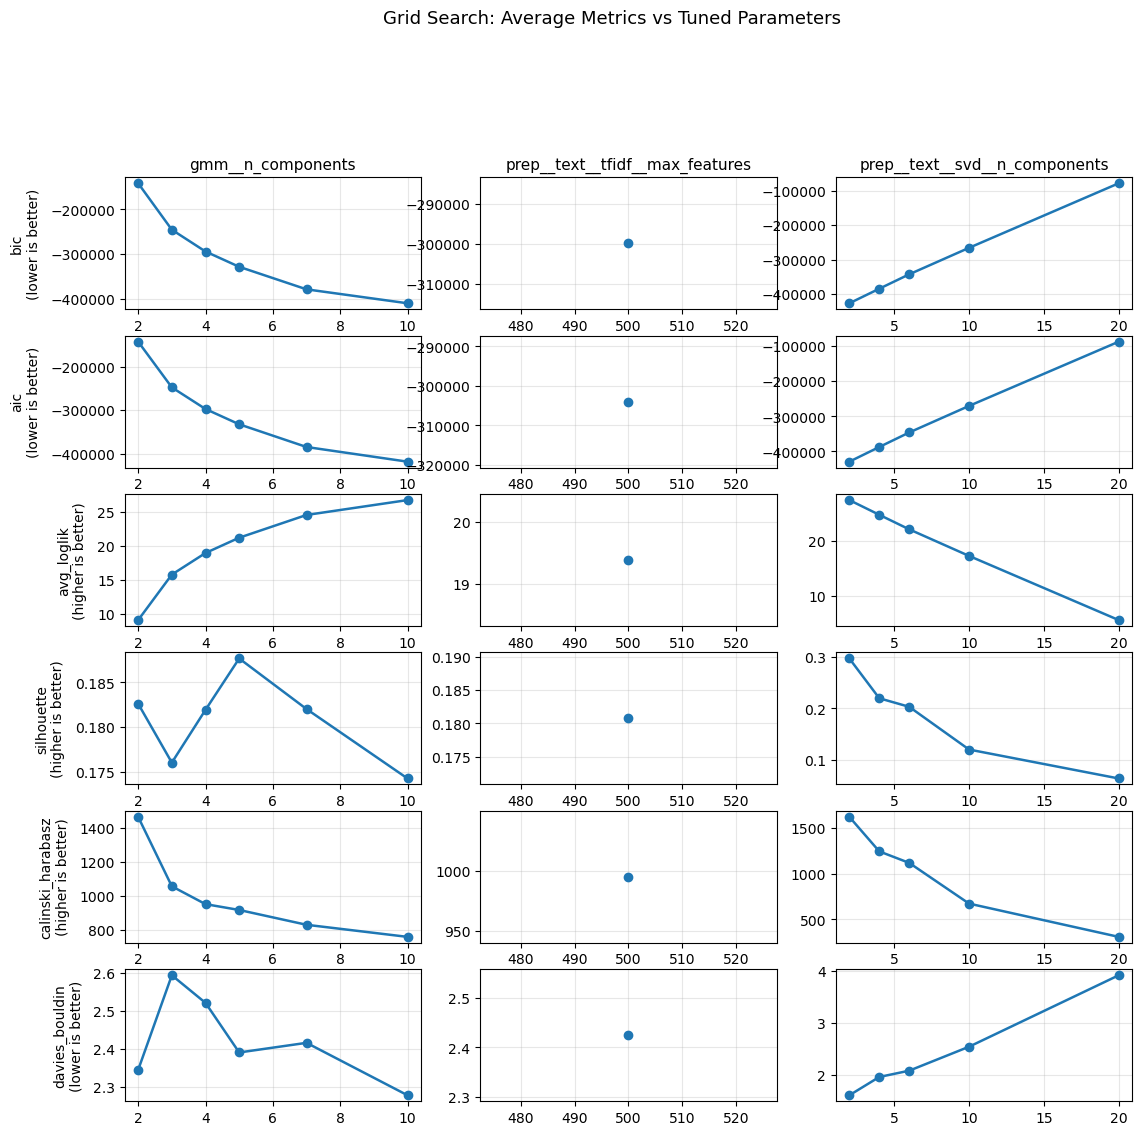



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: bic


  - 3D plot for metric: aic


  - 3D plot for metric: avg_loglik


  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.03 min
- 3D metric plots: 0.21 min

Total runtime: 0.24 minutes.


In [130]:
# Test full grid evaluator

grid_evaluator(gmm_renos_results, model = 'gmm')

### Demolitions

## Grid Search Interpretation Tools

In [94]:
# Define function to extract list of all tested combos 

def list_tested_param_combos(
    results_df: pd.DataFrame,
    model: str = "kmeans") -> pd.DataFrame:
    
    """
    Return a neat table of all unique parameter combinations that were tested,
    with a 'trials' column indicating how many times each combo appeared.
    """

    # --- Pick defaults based on model ---
    if model == "kmeans":
        param_cols = (
            "kmeans__n_clusters",
            "prep__text__svd__n_components",
            "prep__text__tfidf__max_features",
        )
    elif model == "gmm":
        param_cols = (
            "gmm__n_components",
            "gmm__covariance_type",
            "gmm__reg_covar",
            "gmm__n_init",
            "prep__text__svd__n_components",
            "prep__text__tfidf__max_features",
        )
    elif model == 'agg':
        param_cols = (
            "agg__n_clusters",
            "agg__linkage",
            "agg__metric",        
            "prep__text__svd__n_components",
            "prep__text__tfidf__max_features",
        )
    elif model == "dbscan":
        param_cols = (
            "dbscan__eps",
            "dbscan__min_samples",
            "prep__text__svd__n_components",
            "prep__text__tfidf__max_features",
        )
        
    df = results_df.copy()

    # Collect parameter columns
    subset_cols = [c for c in param_cols if c in df.columns]

    # Convert numeric-like params to numeric; leave categorical as-is
    categorical_cols = {
        "gmm__covariance_type", "agg__linkage", "agg__metric"
    }
    for c in subset_cols:
        if c not in categorical_cols:
            df[c] = pd.to_numeric(df[c])

    combos = (
        df.dropna(subset=subset_cols)
          .groupby(subset_cols, as_index=False)
          .size()
          .rename(columns={"size": "trials"})
          .sort_values(subset_cols)
          .reset_index(drop=True)
    )

    # Cast integer-like floats to int for pretty printing
    for c in subset_cols:
        if pd.api.types.is_float_dtype(combos[c]) and (combos[c] % 1 == 0).all():
            combos[c] = combos[c].astype(int)

    print(f"{len(combos)} unique parameter combinations found.")
    return combos

In [85]:
# Define function to read grid search results csv as a dataframe

def read_grid_results_csv(folder,
                          name,
                          filepath = "C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS", 
                          skiprows = 7):
   
    """
    Read a grid search results CSV (with metadata in the first rows).
    """

    full_path = f"{filepath}/{folder}/{name}"
    
    # Peek through file until we find the header row of the results
    with open(full_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    header_row = None
    for i, line in enumerate(lines):
        # detect by presence of known column names
        if "inertia" in line and "silhouette" in line:
            header_row = i
            break

    if header_row is None:
        raise ValueError("Could not detect the results table header in the file.")

    # Now read with skiprows = header_row
    df = pd.read_csv(full_path, skiprows=header_row)

    return df

In [27]:
# Define function to save grid search results csv

def save_grid_results_csv(results_df, param_grid, 
                          filepath = "C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS",
                          filename = "grid_search_results",
                             title = "Grid search results"):
    
    """
    Save a CSV with the parameter grid written at the top, followed by the grid search results DataFrame
    """

    filepath = filepath + '/' + filename
    
    # Make param grid readable
    header_lines = []
    header_lines.append(title)
    header_lines.append(f"Timestamp: {datetime.now().isoformat(timespec='seconds')}")
    header_lines.append("Parameter Grid:")
    for k in sorted(param_grid.keys()):
        v = param_grid[k]
        # prepend comma so Excel/CSV viewers start params in column B
        header_lines.append(f",- {k}: {json.dumps(v)}")
    header_lines.append("")  # blank line before the DataFrame

    # Write header + DataFrame to one CSV file
    with open(filepath, "w", encoding="utf-8", newline="") as f:
        f.write("\n".join(header_lines) + "\n")
        results_df.to_csv(f, index=False)

    print(f"Saved grid results to: {filepath}")

In [104]:
# Define function to check optimal parameter combo according to each metric

def print_top_configs(results_df, top_k = 1,
                      model = 'kmeans'):
    
    """
    Print the top parameter combos according to each metric in results_df
    """
    
    # Defaults by model
    if model == "kmeans":
        metric_cols = ("silhouette", "calinski_harabasz", "davies_bouldin", "inertia")
    elif model == "gmm":
        metric_cols = ("bic", "aic", "avg_loglik", "silhouette", "calinski_harabasz", "davies_bouldin")
    elif model in ("agg", "agglomerative"):
        metric_cols = ("silhouette", "calinski_harabasz", "davies_bouldin")
    elif model == "dbscan":
        metric_cols = ("silhouette", "calinski_harabasz", "davies_bouldin")

    # Which direction is better for each metric?
    higher_better = {
        "silhouette": True,
        "calinski_harabasz": True,
        "davies_bouldin": False,
        "inertia": False,
        "aic": False,
        "bic": False,
        "avg_loglik": True,
    }

    # Columns that are *not* params (we won't print them as params)
    non_param_cols = set(metric_cols) | {"fit_time_s", "n_clusters_found", "index"}

    # Auto-detect param columns
    param_cols = [c for c in results_df.columns if c not in non_param_cols]

    print("\n=== Top parameter configurations by metric ===")
    
    for m in metric_cols:
        dfm = results_df.dropna(subset=[m]).copy()
        asc = not higher_better.get(m, True)  # lower is better -> ascending True
        top = dfm.sort_values(m, ascending=asc).head(top_k)

        print(f"\nMetric: {m}  ({'higher' if not asc else 'lower'} is better)")
        for i, row in top.iterrows():
            params_str = ", ".join(f"{p}={row[p]}" for p in param_cols)
            fit_min = (row.get("fit_time_s", float('nan')) or float('nan')) / 60
            print(f"  • {m}={row[m]:.4f}  | {params_str}  | time={fit_min:.2f} min")

In [118]:
# Define function to plot metric trends after grid search

def plot_metric_trends(results_df, model = 'kmeans'):
    """
    Plot average metrics vs each tuned parameter.
    """

    if model == "kmeans":
        metric_cols = ["silhouette", "calinski_harabasz", "davies_bouldin", "inertia"]
        param_cols  = ["kmeans__n_clusters",
                       "prep__text__tfidf__max_features",
                       "prep__text__svd__n_components"]

    elif model == "gmm":
        metric_cols = ["bic", "aic", "avg_loglik", "silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols  = ["gmm__n_components",
                       "prep__text__tfidf__max_features",
                       "prep__text__svd__n_components"]

    elif model == "agg":
        metric_cols = ["silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols  = ["agg__n_clusters",
                       "agg__linkage",
                       "agg__metric",
                       "prep__text__tfidf__max_features",
                       "prep__text__svd__n_components"]

    elif model == "dbscan":
        metric_cols = ["silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols  = ["dbscan__eps",
                       "dbscan__min_samples",
                       "prep__text__tfidf__max_features",
                       "prep__text__svd__n_components"]

    # Keep only those that actually exist in the df
    metric_cols = [m for m in metric_cols if m in results_df.columns]
    param_cols  = [p for p in param_cols if p in results_df.columns]
    
    n_rows = len(metric_cols)
    n_cols = len(param_cols)

    # increase vertical size to give rows more breathing room
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 12), squeeze=False)

    metric_notes = {
        "silhouette": "(higher is better)",
        "calinski_harabasz": "(higher is better)",
        "davies_bouldin": "(lower is better)",
        "inertia": "(lower is better)",
        "aic": "(lower is better)",
        "bic": "(lower is better)",
        "avg_loglik": "(higher is better)",
    }
    
    for r, metric in enumerate(metric_cols):
        for c, param in enumerate(param_cols):
            ax = axes[r, c]

            if param not in results_df.columns or metric not in results_df.columns:
                ax.set_visible(False)
                continue

            gp = (results_df[[param, metric]]
                  .dropna()
                  .groupby(param, as_index=False)
                  .mean())

            if gp.empty:
                ax.set_visible(False)
                continue

            # numeric x if possible; else treat as categorical
            try:
                gp[param] = pd.to_numeric(gp[param])
                gp = gp.sort_values(param)
                xvals = gp[param]
            except Exception:
                gp[param] = gp[param].astype(str)
                gp = gp.sort_values(param)
                xvals = gp[param]

            ax.plot(xvals, gp[metric], marker='o', linewidth=1.8)
            ax.grid(True, alpha=0.3)

            if r == 0:
                ax.set_title(param, fontsize=11)

            if c == 0:
                # 2-line vertical y-label: metric on line 1, note on line 2
                note = metric_notes.get(metric, "")
                ax.set_ylabel(f"{metric}\n{note}", fontsize=10, rotation=90,
                              va="center", ha="center")
                ax.yaxis.labelpad = 18  # add some space from tick labels

            ax.set_xlabel("")

    fig.suptitle("Grid Search: Average Metrics vs Tuned Parameters", fontsize=13, y=1.02)
    plt.show()


In [119]:
# Define function to print 3D scatter plot of grid search

def plot_grid_3d_metric(results_df,
                        metric,
                        model = "kmeans"):
    """
    3D Plotly scatter of grid search results
    """

    # Choose default param columns by model
    x_col = "prep__text__tfidf__max_features"
    y_col = "prep__text__svd__n_components"
    
    if model == "kmeans":
        z_col = "kmeans__n_clusters"
    elif model == "gmm":
        z_col = "gmm__n_components"
    elif model in ("agg", "agglomerative"):
        z_col = "agg__n_clusters"
    elif model == "dbscan":
        z_col = "dbscan__min_samples"
    else:
        # fallback: first available
        for cand in ["kmeans__n_clusters","gmm__n_components","agg__n_clusters","dbscan__min_samples"]:
            if cand in results_df.columns:
                z_col = cand
                break
        else:
            raise ValueError("No suitable z-axis parameter column found.")
    
    param_cols = (x_col, y_col, z_col)

    # Basic checks
    missing = [c for c in (x_col, y_col, z_col, metric) if c not in results_df.columns]
    if missing:
        raise ValueError(f"Missing required column(s): {missing}")

    df = results_df.dropna(subset=[metric]).copy()

    # Keep originals for hover
    df["_x_orig"] = df[x_col]
    df["_y_orig"] = df[y_col]
    df["_z_orig"] = df[z_col]

    # Simple min–max scaling
    for src, dst in [(x_col, "x_scaled"), (y_col, "y_scaled"), (z_col, "z_scaled")]:
        s = pd.to_numeric(df[src], errors="coerce")
        lo, hi = s.min(), s.max()
        denom = (hi - lo) if pd.notna(hi) and pd.notna(lo) else np.nan
        if pd.isna(denom) or denom == 0:
            df[dst] = 0.0  # flat axis if only one value
        else:
            df[dst] = (s - lo) / denom

    # Metric direction (for colorscale)
    higher_better = {
        "silhouette": True,
        "calinski_harabasz": True,
        "davies_bouldin": False,
        "inertia": False,
        "aic": False,
        "bic": False,
        "avg_loglik": True,
    }
    hb = higher_better.get(metric, True)
    colorscale = "Viridis" if hb else "Viridis_r"

    # axis label map
    axis_labels = {
        "prep__text__tfidf__max_features": "tfidf_feats",
        "prep__text__svd__n_components": "svd_comp",
        "kmeans__n_clusters": "n_clusters",
        "gmm__n_components": "n_components",
        "agg__n_clusters": "n_clusters",
        "dbscan__min_samples": "min_samples",
    }

    fig = px.scatter_3d(
        df,
        x="x_scaled", y="y_scaled", z="z_scaled",
        color=metric,
        color_continuous_scale=colorscale,
        title=f"Grid Search 3D: {metric} ({'higher' if hb else 'lower'} is better)",
        hover_data={
            metric: ':.4f',
            x_col: True, y_col: True, z_col: True,
            "_x_orig": False, "_y_orig": False, "_z_orig": False,
        },
        opacity=0.85
    )

    fig.update_traces(marker=dict(size=4))
    fig.update_layout(
        scene=dict(
            xaxis=dict(title=axis_labels.get(x_col, x_col), range=[0, 1]),
            yaxis=dict(title=axis_labels.get(y_col, y_col), range=[0, 1]),
            zaxis=dict(title=axis_labels.get(z_col, z_col), range=[0, 1]),
        ),
        coloraxis_colorbar=dict(title=metric)
    )
    return fig



In [124]:
# Define function to run all grid search interpretation tools

def grid_evaluator(results_df,
                   model="kmeans",
                   run_print=True,
                   run_trends=True,
                   run_3d=True,
                   sleep_sec=2.0):
    
    """
    Run a subset of grid interpretation utilities
    """

  # Choose metrics & params by model 
    if model == "kmeans":
        metrics = ["silhouette", "calinski_harabasz", "davies_bouldin", "inertia"]
        param_cols = ["kmeans__n_clusters",
                      "prep__text__tfidf__max_features",
                      "prep__text__svd__n_components"]

    elif model == "gmm":
        metrics = ["bic", "aic", "avg_loglik", "silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols = ["gmm__n_components",
                      "gmm__covariance_type",
                      "prep__text__tfidf__max_features",
                      "prep__text__svd__n_components"]

    elif model in ("agg", "agglomerative"):
        metrics = ["silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols = ["agg__n_clusters",
                      "agg__linkage",
                      "agg__metric",
                      "prep__text__tfidf__max_features",
                      "prep__text__svd__n_components"]

    elif model == "dbscan":
        metrics = ["silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols = ["dbscan__eps",
                      "dbscan__min_samples",
                      "prep__text__tfidf__max_features",
                      "prep__text__svd__n_components"]
    else:
        metric_candidates = ["bic","aic","avg_loglik","silhouette","calinski_harabasz","davies_bouldin","inertia"]
        param_candidates  = ["kmeans__n_clusters",
                             "gmm__n_components","gmm__covariance_type",
                             "agg__n_clusters","agg__linkage","agg__metric",
                             "dbscan__eps","dbscan__min_samples",
                             "prep__text__tfidf__max_features","prep__text__svd__n_components"]
        metrics = [m for m in metric_candidates if m in results_df.columns]
        param_cols = [p for p in param_candidates if p in results_df.columns]

    # Keep only columns that actually exist in the DF
    metrics   = [m for m in metrics   if m in results_df.columns]
    param_cols = [p for p in param_cols if p in results_df.columns]

    runtimes = {}
    start_all = time.time()

    if run_print:
        print("\n\nPrinting top parameter configurations by metric...\n")
        t0 = time.time()
        # Uses its own model-specific defaults; we pass model only
        print_top_configs(results_df, top_k=1, model=model)
        runtimes["Top parameter configs"] = (time.time() - t0) / 60

    if run_trends:
        print("\n\nPlotting metric trends vs tuned parameters...\n")
        t0 = time.time()
        plot_metric_trends(results_df, model=model)
        runtimes["Metric trend plots"] = (time.time() - t0) / 60

    if run_3d:
        if not metrics:
            print("\n\nNo metrics found to render in 3D; skipping.")
        else:
            print("\n\nRendering 3D metric views over the parameter grid...\n")
            t0 = time.time()
            for m in metrics:
                print(f"  - 3D plot for metric: {m}")
                # Let the 3D helper pick axes by model
                fig = plot_grid_3d_metric(results_df, metric=m, model=model)
                fig.show()
                time.sleep(sleep_sec)  # throttle Plotly renders
            runtimes["3D metric plots"] = (time.time() - t0) / 60

    total_min = (time.time() - start_all) / 60
    print("\n\n=== Step runtimes (minutes) ===")
    for name, mins in runtimes.items():
        print(f"- {name}: {mins:.2f} min")
    print(f"\nTotal runtime: {total_min:.2f} minutes.")